# Building, Breaking and Fixing a Neural Network
## Environment Setup + Part 1: Backpropagation From Scratch

# Environment Setup

In [40]:
import os
SEED = 42

import random, glob, json, time, platform
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F

def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)

set_seed(SEED)
print(f"Random seed used throughout this notebook: SEED = {SEED}")

Random seed used throughout this notebook: SEED = 42


In [41]:
print("Python      :", platform.python_version())
print("NumPy       :", np.__version__)
print("pandas      :", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("matplotlib  :", matplotlib.__version__)
print("PyTorch     :", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Default torch device:", DEVICE)
OUT_DIR = "/kaggle/working" if os.path.isdir("/kaggle/working") else "."
FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)
print("Outputs will be saved to:", os.path.abspath(OUT_DIR))

RESULTS = {"seed": SEED} 

Python      : 3.12.13
NumPy       : 2.0.2
pandas      : 2.3.3
scikit-learn: 1.6.1
matplotlib  : 3.10.0
PyTorch     : 2.10.0+cu128
CUDA available: True
Default torch device: cuda
Outputs will be saved to: /kaggle/working


##  Load the data

In [42]:
def find_file(filename, roots=("/kaggle/input", ".")):
    for root in roots:
        hits = sorted(glob.glob(os.path.join(root, "**", filename), recursive=True))
        if hits:
            return hits[0]
    raise FileNotFoundError(
        f"{filename} not found. On Kaggle, add the dataset 'zalando-research/fashionmnist' via 'Add Input'.")

TRAIN_CSV = find_file("fashion-mnist_train.csv")
TEST_CSV  = find_file("fashion-mnist_test.csv")
print("Train file:", TRAIN_CSV)
print("Test  file:", TEST_CSV)

train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)
print("Raw train shape:", train_df.shape, "| Raw test shape:", test_df.shape)

CLASS_NAMES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
NUM_CLASSES = len(CLASS_NAMES)

Train file: /kaggle/input/datasets/wokingspace/fashion-mnist/fashion-mnist_train.csv
Test  file: /kaggle/input/datasets/wokingspace/fashion-mnist/fashion-mnist_test.csv
Raw train shape: (60000, 785) | Raw test shape: (10000, 785)


In [43]:
y_full = train_df["label"].to_numpy().astype(np.int64)
X_full = train_df.drop(columns="label").to_numpy().astype(np.float32) / 255.0

y_test = test_df["label"].to_numpy().astype(np.int64)
X_test = test_df.drop(columns="label").to_numpy().astype(np.float32) / 255.0


X_full = X_full.reshape(-1, 28 * 28)
X_test = X_test.reshape(-1, 28 * 28)

print(f"X_full: {X_full.shape}, dtype={X_full.dtype}, min={X_full.min():.1f}, max={X_full.max():.1f}")
print(f"X_test: {X_test.shape}, dtype={X_test.dtype}, min={X_test.min():.1f}, max={X_test.max():.1f}")
assert X_full.shape[1] == 784 and X_test.shape[1] == 784
assert 0.0 <= X_full.min() and X_full.max() <= 1.0

X_full: (60000, 784), dtype=float32, min=0.0, max=1.0
X_test: (10000, 784), dtype=float32, min=0.0, max=1.0


## Train / validation split (80/20) and the untouched test set

In [44]:
X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full, test_size=0.20, stratify=y_full, random_state=SEED)

print(f"Training set  : {X_train.shape[0]:>6} samples, feature dim = {X_train.shape[1]}")
print(f"Validation set: {X_val.shape[0]:>6} samples, feature dim = {X_val.shape[1]}")
print(f"Test set      : {X_test.shape[0]:>6} samples (held out until Part 7)")

RESULTS["n_train"], RESULTS["n_val"], RESULTS["n_test"] = int(len(y_train)), int(len(y_val)), int(len(y_test))

Training set  :  48000 samples, feature dim = 784
Validation set:  12000 samples, feature dim = 784
Test set      :  10000 samples (held out until Part 7)


In [45]:
def class_counts(y):
    return np.bincount(y, minlength=NUM_CLASSES)

dist = pd.DataFrame({
    "class_id": range(NUM_CLASSES),
    "class_name": CLASS_NAMES,
    "train_count": class_counts(y_train),
    "val_count": class_counts(y_val),
    "test_count": class_counts(y_test),
})
for split in ["train", "val", "test"]:
    dist[f"{split}_%"] = (100 * dist[f"{split}_count"] / dist[f"{split}_count"].sum()).round(2)

total = pd.DataFrame([{"class_id": "", "class_name": "TOTAL",
                       "train_count": len(y_train), "val_count": len(y_val), "test_count": len(y_test),
                       "train_%": 100.0, "val_%": 100.0, "test_%": 100.0}])
dist_table = pd.concat([dist, total], ignore_index=True)
print(dist_table.to_string(index=False))

RESULTS["class_distribution"] = {
    split: dict(zip(CLASS_NAMES, map(int, class_counts(y))))
    for split, y in [("train", y_train), ("val", y_val), ("test", y_test)]}

class_id  class_name  train_count  val_count  test_count   train_%     val_%    test_%
       0 T-shirt/top         4800       1200        1000 1.000e+01 1.000e+01 1.000e+01
       1     Trouser         4800       1200        1000 1.000e+01 1.000e+01 1.000e+01
       2    Pullover         4800       1200        1000 1.000e+01 1.000e+01 1.000e+01
       3       Dress         4800       1200        1000 1.000e+01 1.000e+01 1.000e+01
       4        Coat         4800       1200        1000 1.000e+01 1.000e+01 1.000e+01
       5      Sandal         4800       1200        1000 1.000e+01 1.000e+01 1.000e+01
       6       Shirt         4800       1200        1000 1.000e+01 1.000e+01 1.000e+01
       7     Sneaker         4800       1200        1000 1.000e+01 1.000e+01 1.000e+01
       8         Bag         4800       1200        1000 1.000e+01 1.000e+01 1.000e+01
       9  Ankle boot         4800       1200        1000 1.000e+01 1.000e+01 1.000e+01
               TOTAL        48000      1200

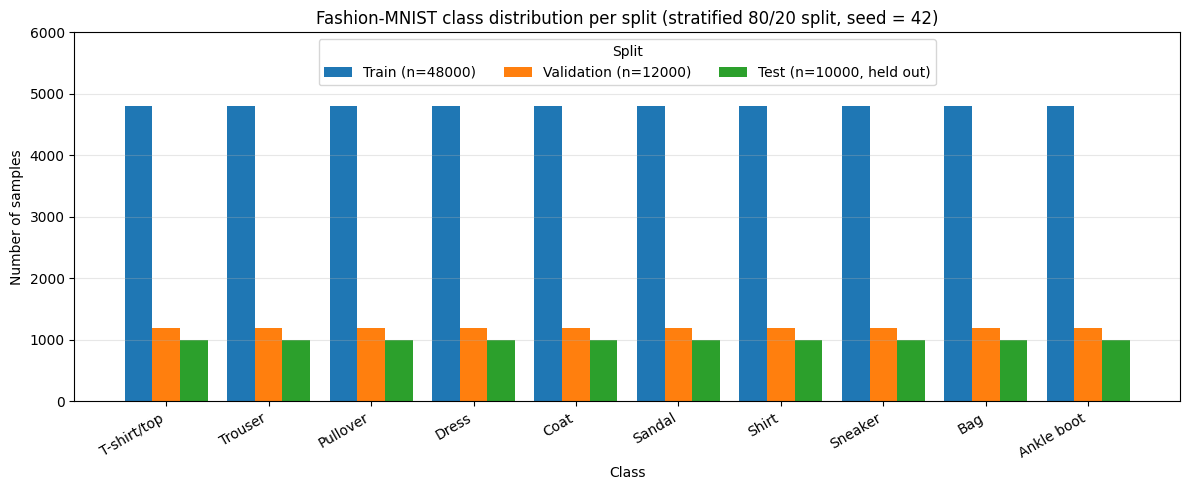

In [46]:
x = np.arange(NUM_CLASSES)
w = 0.27
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w, dist["train_count"], w, label=f"Train (n={len(y_train)})")
ax.bar(x,     dist["val_count"],   w, label=f"Validation (n={len(y_val)})")
ax.bar(x + w, dist["test_count"],  w, label=f"Test (n={len(y_test)}, held out)")
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right")
ax.set_xlabel("Class")
ax.set_ylabel("Number of samples")
ax.set_title("Fashion-MNIST class distribution per split (stratified 80/20 split, seed = 42)")
ax.set_ylim(0, dist["train_count"].max() * 1.25)   # headroom so the legend does not cover bars
ax.legend(title="Split", loc="upper center", ncol=3)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "class_distribution.png"), dpi=150)
plt.show()

**Observation.** Fashion-MNIST is perfectly balanced: each class is exactly 10 % of every split
(4,800 per class in training, 1,200 in validation and 1,000 in test). Stratification preserves this balance
exactly, so plain accuracy is a fair metric and no class re-weighting is needed.

# Part 1: Backpropagation From Scratch (NumPy only)

In [47]:
def init_params(n_in=784, n_hidden=64, n_out=10, seed=SEED):
    rng = np.random.default_rng(seed)
    return {
        "W1": rng.normal(0.0, np.sqrt(2.0 / n_in),     size=(n_in, n_hidden)),
        "b1": np.zeros(n_hidden),
        "W2": rng.normal(0.0, np.sqrt(1.0 / n_hidden), size=(n_hidden, n_out)),
        "b2": np.zeros(n_out),
    }

def relu(z):
    return np.maximum(0.0, z)

def softmax(z):
    z = z - z.max(axis=1, keepdims=True)          
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

def one_hot(y, num_classes=NUM_CLASSES):
    return np.eye(num_classes)[y]

def cross_entropy(logits, y):
    m = logits.max(axis=1, keepdims=True)
    log_sum_exp = m[:, 0] + np.log(np.exp(logits - m).sum(axis=1))
    return float(np.mean(log_sum_exp - logits[np.arange(len(y)), y]))

def forward(params, X):
    # Forward pass.
    Z1 = X @ params["W1"] + params["b1"]
    A1 = relu(Z1)
    Z2 = A1 @ params["W2"] + params["b2"]
    P  = softmax(Z2)
    cache = {"X": X, "Z1": Z1, "A1": A1, "Z2": Z2, "P": P}
    return P, cache

def backward(params, cache, y):
    # Backward pass
    X, Z1, A1, P = cache["X"], cache["Z1"], cache["A1"], cache["P"]
    N = X.shape[0]
    dZ2 = (P - one_hot(y)) / N                    # (N, 10)
    dW2 = A1.T @ dZ2                              # (64, 10)
    db2 = dZ2.sum(axis=0)                         # (10,)
    dA1 = dZ2 @ params["W2"].T                    # (N, 64)
    dZ1 = dA1 * (Z1 > 0)                          # ReLU derivative
    dW1 = X.T @ dZ1                               # (784, 64)
    db1 = dZ1.sum(axis=0)                         # (64,)
    return {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2}

def sgd_update(params, grads, lr):
    for k in params:
        params[k] -= lr * grads[k]

def evaluate(params, X, y):
    _, cache = forward(params, X)
    loss = cross_entropy(cache["Z2"], y)
    acc = float(np.mean(cache["P"].argmax(axis=1) == y))
    return loss, acc
_p = init_params()
_P, _c = forward(_p, np.zeros((3, 784)))
_g = backward(_p, _c, np.array([0, 1, 2]))
for k in _p:
    assert _g[k].shape == _p[k].shape, k
print("Parameter shapes:", {k: v.shape for k, v in _p.items()})
print("Total trainable parameters:", sum(v.size for v in _p.values()))

Parameter shapes: {'W1': (784, 64), 'b1': (64,), 'W2': (64, 10), 'b2': (10,)}
Total trainable parameters: 50890


## Training data: a stratified subset of 5,000 samples

In [48]:
X_sub, _, y_sub, _ = train_test_split(
    X_train, y_train, train_size=5000, stratify=y_train, random_state=SEED)

X_sub = X_sub.astype(np.float64)          
X_val64 = X_val.astype(np.float64)
print("Subset shape:", X_sub.shape)
print("Subset class counts:", dict(zip(CLASS_NAMES, class_counts(y_sub).tolist())))
RESULTS["n_subset"] = int(len(y_sub))

Subset shape: (5000, 784)
Subset class counts: {'T-shirt/top': 500, 'Trouser': 500, 'Pullover': 500, 'Dress': 500, 'Coat': 500, 'Sandal': 500, 'Shirt': 500, 'Sneaker': 500, 'Bag': 500, 'Ankle boot': 500}


## Training function (manual mini-batch gradient descent)

In [49]:
def train_numpy_mlp(X, y, Xv, yv, lr, batch_size=64, epochs=20, hidden=64,
                    init_seed=SEED, shuffle_seed=SEED + 1, verbose=True):
    params = init_params(X.shape[1], hidden, NUM_CLASSES, seed=init_seed)
    init_copy = {k: v.copy() for k, v in params.items()}
    rng = np.random.default_rng(shuffle_seed)
    batch_losses, history = [], []

    def log(epoch):
        tl, ta = evaluate(params, X, y)
        vl, va = evaluate(params, Xv, yv)
        history.append({"epoch": epoch, "train_loss": tl, "train_acc": ta, "val_loss": vl, "val_acc": va})
        if verbose:
            print(f"Epoch {epoch:2d}/{epochs} | train loss {tl:.4f} acc {ta:.4f} | val loss {vl:.4f} acc {va:.4f}")

    log(0)
    n = X.shape[0]
    for epoch in range(1, epochs + 1):
        order = rng.permutation(n)
        for start in range(0, n, batch_size):
            idx = order[start:start + batch_size]
            Xb, yb = X[idx], y[idx]
            P, cache = forward(params, Xb)                 
            batch_losses.append(cross_entropy(cache["Z2"], yb))
            grads = backward(params, cache, yb)           
            sgd_update(params, grads, lr)                  
        log(epoch)
    return params, init_copy, pd.DataFrame(history), np.array(batch_losses)

### Choosing the learning rate

lr = 0.1   | final training loss 0.4708 | epochs where the loss went UP: 10/19
lr = 0.05  | final training loss 0.5225 | epochs where the loss went UP: 10/19
lr = 0.01  | final training loss 0.6010 | epochs where the loss went UP: 1/19


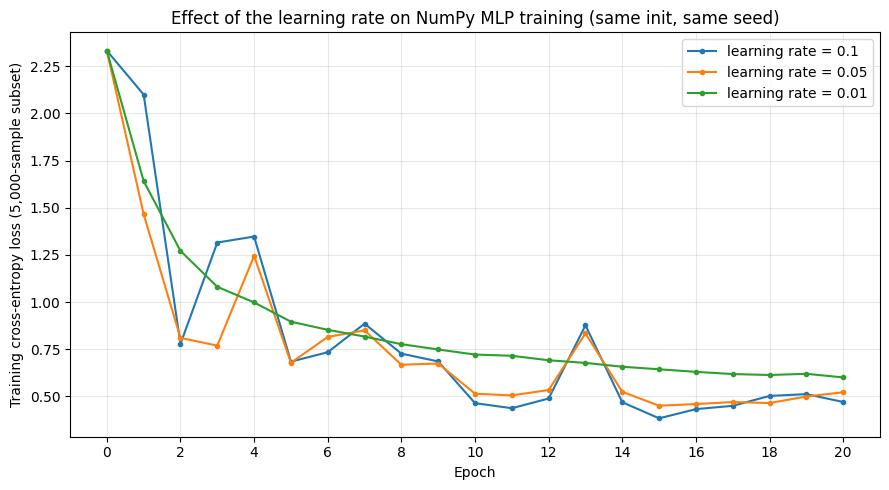

In [50]:
lr_candidates = [0.1, 0.05, 0.01]
lr_runs = {}
for lr in lr_candidates:
    _, _, h, _ = train_numpy_mlp(X_sub, y_sub, X_val64, y_val, lr=lr, verbose=False)
    lr_runs[lr] = h
    tl = h["train_loss"].to_numpy()
    n_increases = int((np.diff(tl[1:]) > 0).sum())
    print(f"lr = {lr:<5} | final training loss {tl[-1]:.4f} | epochs where the loss went UP: {n_increases}/19")

fig, ax = plt.subplots(figsize=(9, 5))
for lr, h in lr_runs.items():
    ax.plot(h["epoch"], h["train_loss"], "o-", ms=3, label=f"learning rate = {lr}")
ax.set_xlabel("Epoch")
ax.set_ylabel("Training cross-entropy loss (5,000-sample subset)")
ax.set_title("Effect of the learning rate on NumPy MLP training (same init, same seed)")
ax.set_xticks(range(0, 21, 2))
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "part1_learning_rate_choice.png"), dpi=150)
plt.show()

RESULTS["part1_lr_comparison_final_train_loss"] = {str(lr): float(h["train_loss"].iloc[-1]) for lr, h in lr_runs.items()}

In [51]:
HIDDEN, LR, BATCH_SIZE, EPOCHS = 64, 0.01, 64, 20
RESULTS["hyperparameters"] = {"hidden": HIDDEN, "lr": LR, "batch_size": BATCH_SIZE, "epochs": EPOCHS,
                              "init_seed": SEED, "shuffle_seed": SEED + 1}

t0 = time.time()
params, initial_params, hist_df, batch_losses = train_numpy_mlp(
    X_sub, y_sub, X_val64, y_val, lr=LR, batch_size=BATCH_SIZE, epochs=EPOCHS, hidden=HIDDEN)
print(f"\nInitial loss = {hist_df['train_loss'].iloc[0]:.4f}  (ln 10 = {np.log(10):.4f})")
print(f"Training time: {time.time() - t0:.1f} s for {len(batch_losses)} mini-batch updates")

last = hist_df.iloc[-1]
RESULTS["part1_training"] = {
    "initial_train_loss": float(hist_df["train_loss"].iloc[0]),
    "final_train_loss": float(last["train_loss"]), "final_train_acc": float(last["train_acc"]),
    "final_val_loss": float(last["val_loss"]),     "final_val_acc": float(last["val_acc"]),
}

Epoch  0/20 | train loss 2.3325 acc 0.1728 | val loss 2.3300 acc 0.1767
Epoch  1/20 | train loss 1.6417 acc 0.5426 | val loss 1.6375 acc 0.5350
Epoch  2/20 | train loss 1.2717 acc 0.6446 | val loss 1.2671 acc 0.6386
Epoch  3/20 | train loss 1.0813 acc 0.6678 | val loss 1.0780 acc 0.6566
Epoch  4/20 | train loss 0.9984 acc 0.6708 | val loss 0.9969 acc 0.6653
Epoch  5/20 | train loss 0.8963 acc 0.7208 | val loss 0.8931 acc 0.7161
Epoch  6/20 | train loss 0.8533 acc 0.7288 | val loss 0.8514 acc 0.7176
Epoch  7/20 | train loss 0.8175 acc 0.7162 | val loss 0.8185 acc 0.7067
Epoch  8/20 | train loss 0.7773 acc 0.7430 | val loss 0.7785 acc 0.7372
Epoch  9/20 | train loss 0.7491 acc 0.7612 | val loss 0.7501 acc 0.7550
Epoch 10/20 | train loss 0.7222 acc 0.7686 | val loss 0.7236 acc 0.7632
Epoch 11/20 | train loss 0.7158 acc 0.7646 | val loss 0.7210 acc 0.7600
Epoch 12/20 | train loss 0.6920 acc 0.7762 | val loss 0.6934 acc 0.7712
Epoch 13/20 | train loss 0.6780 acc 0.7786 | val loss 0.6825 acc

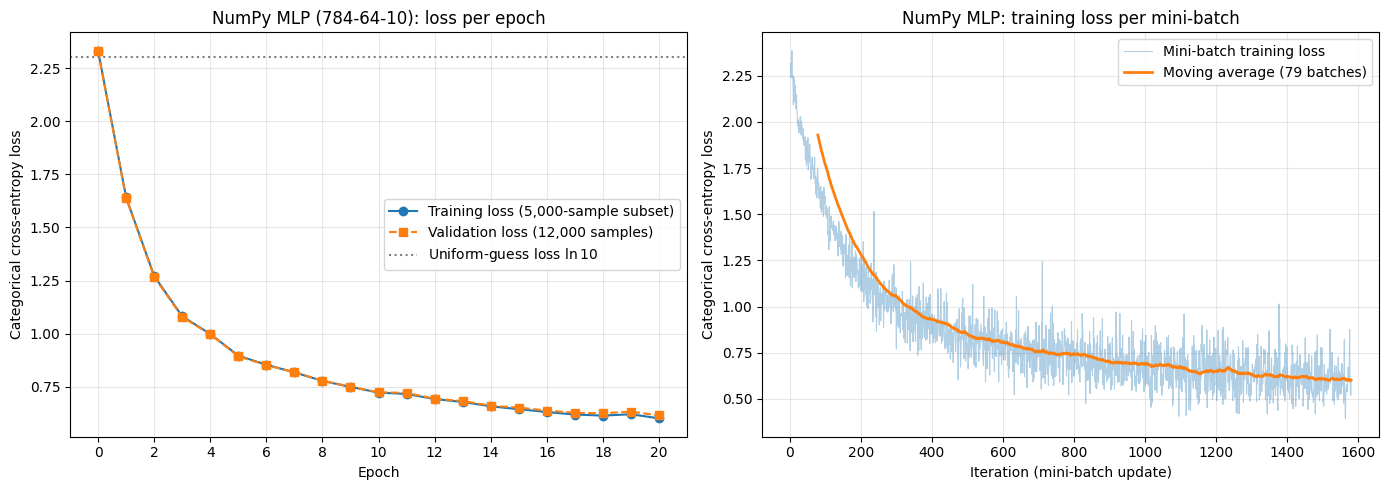

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(hist_df["epoch"], hist_df["train_loss"], "o-", label="Training loss (5,000-sample subset)")
ax.plot(hist_df["epoch"], hist_df["val_loss"], "s--", label="Validation loss (12,000 samples)")
ax.axhline(np.log(10), color="gray", ls=":", label=r"Uniform-guess loss $\ln 10$")
ax.set_xlabel("Epoch")
ax.set_ylabel("Categorical cross-entropy loss")
ax.set_title("NumPy MLP (784-64-10): loss per epoch")
ax.set_xticks(range(0, EPOCHS + 1, 2))
ax.grid(alpha=0.3)
ax.legend()

ax = axes[1]
it = np.arange(1, len(batch_losses) + 1)
window = 79   # about one epoch
smooth = np.convolve(batch_losses, np.ones(window) / window, mode="valid")
ax.plot(it, batch_losses, alpha=0.35, lw=0.8, label="Mini-batch training loss")
ax.plot(it[window - 1:], smooth, lw=2, label=f"Moving average ({window} batches)")
ax.set_xlabel("Iteration (mini-batch update)")
ax.set_ylabel("Categorical cross-entropy loss")
ax.set_title("NumPy MLP: training loss per mini-batch")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "part1_training_loss.png"), dpi=150)
plt.show()

In [53]:
print(hist_df.round(4).to_string(index=False))

 epoch  train_loss  train_acc  val_loss   val_acc
     0   2.333e+00  1.728e-01 2.330e+00 1.767e-01
     1   1.642e+00  5.426e-01 1.637e+00 5.350e-01
     2   1.272e+00  6.446e-01 1.267e+00 6.386e-01
     3   1.081e+00  6.678e-01 1.078e+00 6.566e-01
     4   9.984e-01  6.708e-01 9.969e-01 6.652e-01
     5   8.963e-01  7.208e-01 8.931e-01 7.161e-01
     6   8.533e-01  7.288e-01 8.514e-01 7.176e-01
     7   8.175e-01  7.162e-01 8.185e-01 7.067e-01
     8   7.773e-01  7.430e-01 7.785e-01 7.372e-01
     9   7.491e-01  7.612e-01 7.501e-01 7.550e-01
    10   7.222e-01  7.686e-01 7.236e-01 7.632e-01
    11   7.158e-01  7.646e-01 7.210e-01 7.600e-01
    12   6.920e-01  7.762e-01 6.934e-01 7.712e-01
    13   6.780e-01  7.786e-01 6.825e-01 7.712e-01
    14   6.576e-01  7.938e-01 6.605e-01 7.902e-01
    15   6.442e-01  7.976e-01 6.515e-01 7.898e-01
    16   6.306e-01  7.984e-01 6.377e-01 7.922e-01
    17   6.189e-01  8.014e-01 6.270e-01 7.958e-01
    18   6.139e-01  8.006e-01 6.249e-01 7.928e-01


## Gradient verification against PyTorch

In [54]:
class TorchMLP(nn.Module):
    def __init__(self, n_in=784, n_hidden=64, n_out=10):
        super().__init__()
        self.fc1 = nn.Linear(n_in, n_hidden)
        self.fc2 = nn.Linear(n_hidden, n_out)

    def forward(self, x):
        return self.fc2(F.relu(self.fc1(x)))

def load_numpy_weights(model, p):
    dev, dt = model.fc1.weight.device, model.fc1.weight.dtype
    with torch.no_grad():
        model.fc1.weight.copy_(torch.tensor(p["W1"].T, dtype=dt, device=dev))
        model.fc1.bias.copy_(torch.tensor(p["b1"], dtype=dt, device=dev))
        model.fc2.weight.copy_(torch.tensor(p["W2"].T, dtype=dt, device=dev))
        model.fc2.bias.copy_(torch.tensor(p["b2"], dtype=dt, device=dev))
check_rng = np.random.default_rng(SEED + 2)
check_idx = check_rng.choice(len(y_sub), size=64, replace=False)
Xc, yc = X_sub[check_idx], y_sub[check_idx]
print("Gradient-check batch:", Xc.shape, "| labels in batch:", np.bincount(yc, minlength=10).tolist())
P_np, cache_np = forward(initial_params, Xc)
loss_np = cross_entropy(cache_np["Z2"], yc)
grads_np = backward(initial_params, cache_np, yc)
print(f"NumPy loss on the batch: {loss_np:.12f}")

Gradient-check batch: (64, 784) | labels in batch: [6, 6, 12, 4, 6, 6, 8, 6, 6, 4]
NumPy loss on the batch: 2.312668872744


In [55]:
def torch_gradients(p, X, y, device, dtype):
    torch.manual_seed(SEED)
    model = TorchMLP(784, HIDDEN, NUM_CLASSES).to(device=device, dtype=dtype)
    load_numpy_weights(model, p)
    w_diff = max(np.abs(model.fc1.weight.detach().cpu().double().numpy().T - p["W1"]).max(),
                 np.abs(model.fc2.weight.detach().cpu().double().numpy().T - p["W2"]).max())

    Xt = torch.tensor(X, dtype=dtype, device=device)
    yt = torch.tensor(y, dtype=torch.long, device=device)
    model.zero_grad()
    logits = model(Xt)                              # forward pass
    loss = F.cross_entropy(logits, yt)              # softmax + categorical CE, mean over batch
    loss.backward()                                 # backward pass (autograd)

    g = {"W1": model.fc1.weight.grad.T, "b1": model.fc1.bias.grad,
         "W2": model.fc2.weight.grad.T, "b2": model.fc2.bias.grad}
    g = {k: v.detach().cpu().double().numpy() for k, v in g.items()}
    probs = torch.softmax(logits, dim=1).detach().cpu().double().numpy()
    return loss.item(), probs, g, w_diff

def compare(label, device, dtype):
    loss_t, probs_t, grads_t, w_diff = torch_gradients(initial_params, Xc, yc, device, dtype)
    rows = []
    for k in ["W1", "b1", "W2", "b2"]:
        a, b = grads_np[k], grads_t[k]
        rows.append({
            "run": label, "parameter": k, "shape": str(a.shape),
            "max_abs_diff": np.abs(a - b).max(),
            "max_abs_grad": np.abs(b).max(),
            "rel_error": np.linalg.norm(a - b) / (np.linalg.norm(a) + np.linalg.norm(b) + 1e-300),
        })
    print(f"[{label}] initial-weight max diff: {w_diff:.3e} | loss NumPy {loss_np:.12f} vs "
          f"torch {loss_t:.12f} (|diff| = {abs(loss_np - loss_t):.3e}) | "
          f"max |prob diff| = {np.abs(P_np - probs_t).max():.3e}")
    return pd.DataFrame(rows)

runs = [("CPU float64", torch.device("cpu"), torch.float64)]
if torch.cuda.is_available():
    runs.append(("GPU float64", torch.device("cuda"), torch.float64))
runs.append(("CPU float32 (precision reference)", torch.device("cpu"), torch.float32))

grad_check = pd.concat([compare(*r) for r in runs], ignore_index=True)
pd.set_option("display.float_format", lambda v: f"{v:.3e}")
print()
print(grad_check.to_string(index=False))

[CPU float64] initial-weight max diff: 0.000e+00 | loss NumPy 2.312668872744 vs torch 2.312668872744 (|diff| = 0.000e+00) | max |prob diff| = 1.665e-16
[GPU float64] initial-weight max diff: 0.000e+00 | loss NumPy 2.312668872744 vs torch 2.312668872744 (|diff| = 0.000e+00) | max |prob diff| = 1.665e-16
[CPU float32 (precision reference)] initial-weight max diff: 1.490e-08 | loss NumPy 2.312668872744 vs torch 2.312668800354 (|diff| = 7.239e-08) | max |prob diff| = 7.214e-08

                              run parameter     shape  max_abs_diff  max_abs_grad  rel_error
                      CPU float64        W1 (784, 64)     1.735e-17     4.926e-02  9.574e-17
                      CPU float64        b1     (64,)     1.388e-17     4.362e-02  1.213e-16
                      CPU float64        W2  (64, 10)     7.633e-17     1.340e-01  1.614e-16
                      CPU float64        b2     (10,)     6.939e-17     1.009e-01  2.982e-16
                      GPU float64        W1 (784, 64)   

In [56]:
# Compare NumPy and PyTorch gradients
_, _, grads_torch, _ = torch_gradients(initial_params, Xc, yc, torch.device("cpu"), torch.float64)

for name in ["W1", "b1", "W2", "b2"]:
    difference = np.max(
        np.abs(grads_np[name] - grads_torch[name])
    )
    
    print(f"{name} maximum difference: {difference:.3e}")

W1 maximum difference: 1.735e-17
b1 maximum difference: 1.388e-17
W2 maximum difference: 7.633e-17
b2 maximum difference: 6.939e-17


In [57]:
main = grad_check[grad_check["run"] == "CPU float64"].set_index("parameter")
print("Maximum absolute difference |grad_NumPy - grad_PyTorch|  (same batch, same initial weights, float64)")
for k in ["W1", "b1", "W2", "b2"]:
    kind = "weight matrix" if k.startswith("W") else "bias vector  "
    print(f"  {k} ({kind}) shape {main.loc[k, 'shape']:>10}: {main.loc[k, 'max_abs_diff']:.3e}")

overall_max = float(main["max_abs_diff"].max())
max_weight_matrix = float(main.loc[["W1", "W2"], "max_abs_diff"].max())
print(f"\nLargest difference over the two weight matrices: {max_weight_matrix:.3e}")
print(f"Largest difference over all parameters         : {overall_max:.3e}")

TOL = 1e-10
verdict = "CORRECT" if overall_max < TOL else "SUSPECT - investigate"
print(f"Verdict (threshold {TOL:.0e}): {verdict}")

RESULTS["gradient_check"] = {
    r: {k: float(v) for k, v in grad_check[grad_check["run"] == r].set_index("parameter")["max_abs_diff"].items()}
    for r in grad_check["run"].unique()}
RESULTS["gradient_check_max_abs_diff_float64"] = overall_max

Maximum absolute difference |grad_NumPy - grad_PyTorch|  (same batch, same initial weights, float64)
  W1 (weight matrix) shape  (784, 64): 1.735e-17
  b1 (bias vector  ) shape      (64,): 1.388e-17
  W2 (weight matrix) shape   (64, 10): 7.633e-17
  b2 (bias vector  ) shape      (10,): 6.939e-17

Largest difference over the two weight matrices: 7.633e-17
Largest difference over all parameters         : 7.633e-17
Verdict (threshold 1e-10): CORRECT


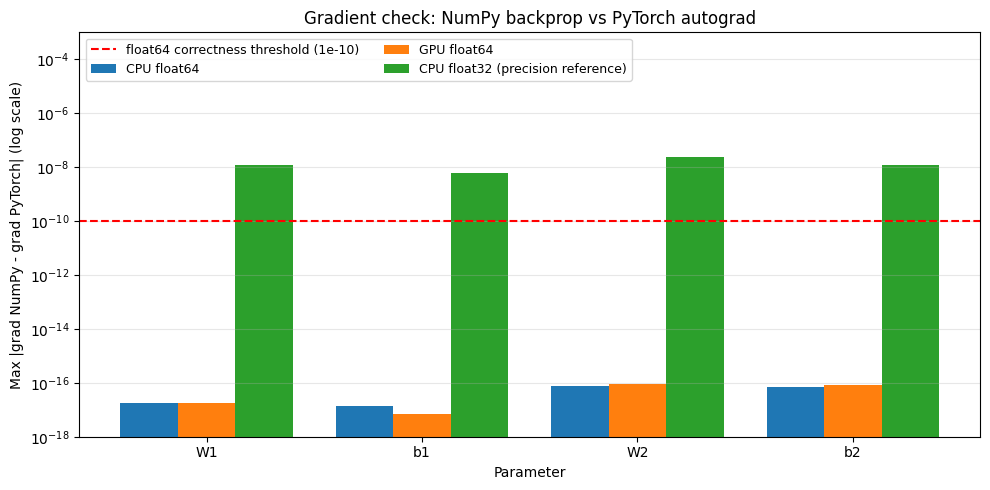

In [58]:
fig, ax = plt.subplots(figsize=(10, 5))
params_order = ["W1", "b1", "W2", "b2"]
run_names = grad_check["run"].unique()
w = 0.8 / len(run_names)
xpos = np.arange(len(params_order))
for i, r in enumerate(run_names):
    vals = grad_check[grad_check["run"] == r].set_index("parameter").loc[params_order, "max_abs_diff"]
    ax.bar(xpos + (i - (len(run_names) - 1) / 2) * w, np.maximum(vals.values, 1e-20), w, label=r)
ax.axhline(TOL, color="red", ls="--", label=f"float64 correctness threshold ({TOL:.0e})")
ax.set_yscale("log")
ax.set_ylim(1e-18, 1e-3)
ax.set_xticks(xpos)
ax.set_xticklabels(params_order)
ax.set_xlabel("Parameter")
ax.set_ylabel("Max |grad NumPy - grad PyTorch| (log scale)")
ax.set_title("Gradient check: NumPy backprop vs PyTorch autograd")
ax.legend(fontsize=9, loc="upper left", ncol=2)
ax.grid(axis="y", alpha=0.3, which="both")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "part1_gradient_check.png"), dpi=150)
plt.show()

### Extra sanity check: finite differences

In [59]:
def numeric_grad_check(p, X, y, n_checks=10, eps=1e-5, seed=SEED + 3):
    rng = np.random.default_rng(seed)
    _, cache = forward(p, X)
    analytic = backward(p, cache, y)
    rows = []
    for k in ["W1", "b1", "W2", "b2"]:
        errs = []
        for _ in range(n_checks):
            idx = tuple(rng.integers(0, s) for s in p[k].shape)
            q = {kk: vv.copy() for kk, vv in p.items()}
            q[k][idx] += eps; lp = cross_entropy(forward(q, X)[1]["Z2"], y)
            q[k][idx] -= 2 * eps; lm = cross_entropy(forward(q, X)[1]["Z2"], y)
            num = (lp - lm) / (2 * eps)
            ana = analytic[k][idx]
            errs.append(abs(num - ana) / max(1e-12, abs(num) + abs(ana)))
        rows.append({"parameter": k, "entries_checked": n_checks, "max_relative_error": max(errs)})
    return pd.DataFrame(rows)

fd = numeric_grad_check(initial_params, Xc, yc)
print(fd.to_string(index=False))
RESULTS["finite_difference_max_rel_error"] = float(fd["max_relative_error"].max())

parameter  entries_checked  max_relative_error
       W1               10           2.065e-08
       b1               10           1.203e-08
       W2               10           3.253e-08
       b2               10           9.510e-10


## Results and Discussion

The gradients from the NumPy network were compared with the gradients from
PyTorch using the same weights and data. The differences were very small,
which shows that the backpropagation calculations in NumPy are correct.

The NumPy and PyTorch loss values were also almost the same, so the forward
pass and loss calculation are working correctly.

The small differences are caused by floating-point calculations. The training
loss decreased during the 20 epochs, which shows that the network was learning.

In [60]:
r = RESULTS
gc = r["gradient_check"]["CPU float64"]
print("PART 1 CONCLUSION")
print(f"Seed: {r['seed']} | splits: train={r['n_train']}, val={r['n_val']}, test={r['n_test']} "
      f"| NumPy training subset: {r['n_subset']}")
t = r["part1_training"]
print(f"NumPy MLP after {r['hyperparameters']['epochs']} epochs: training loss "
      f"{t['initial_train_loss']:.4f} -> {t['final_train_loss']:.4f}, "
      f"train acc {t['final_train_acc']:.4f}, val acc {t['final_val_acc']:.4f}")
print("Max |NumPy grad - PyTorch grad| (float64): " +
      ", ".join(f"{k} = {v:.2e}" for k, v in gc.items()))
print(f"Maximum difference obtained: {r['gradient_check_max_abs_diff_float64']:.2e} "
      f"(float64 machine epsilon = {np.finfo(np.float64).eps:.2e})")
print(f"Finite-difference max relative error: {r['finite_difference_max_rel_error']:.2e}")
ok = r["gradient_check_max_abs_diff_float64"] < 1e-10
print("=> The hand-written backpropagation is", "CORRECT." if ok else "NOT verified.")

PART 1 CONCLUSION
Seed: 42 | splits: train=48000, val=12000, test=10000 | NumPy training subset: 5000
NumPy MLP after 20 epochs: training loss 2.3325 -> 0.6010, train acc 0.8020, val acc 0.7984
Max |NumPy grad - PyTorch grad| (float64): W1 = 1.73e-17, b1 = 1.39e-17, W2 = 7.63e-17, b2 = 6.94e-17
Maximum difference obtained: 7.63e-17 (float64 machine epsilon = 2.22e-16)
Finite-difference max relative error: 3.25e-08
=> The hand-written backpropagation is CORRECT.


In [61]:
def to_py(o):
    if isinstance(o, dict):  return {str(k): to_py(v) for k, v in o.items()}
    if isinstance(o, (np.floating,)): return float(o)
    if isinstance(o, (np.integer,)):  return int(o)
    return o

with open(os.path.join(OUT_DIR, "part1_results.json"), "w") as f:
    json.dump(to_py(RESULTS), f, indent=2)
hist_df.to_csv(os.path.join(OUT_DIR, "part1_training_history.csv"), index=False)
grad_check.to_csv(os.path.join(OUT_DIR, "part1_gradient_check.csv"), index=False)
print("Saved: part1_results.json, part1_training_history.csv, part1_gradient_check.csv, figures/*.png")

Saved: part1_results.json, part1_training_history.csv, part1_gradient_check.csv, figures/*.png


### Notes for the following parts
* `X_train, y_train` (48,000), `X_val, y_val` (12,000) and `X_test, y_test` (10,000) are ready for later
  parts. The test arrays have **not** been used by any model and should stay unused until Part 7.

# Part 2: Baseline Model and Activation Study

In [62]:
from torch.utils.data import TensorDataset, DataLoader
Xtr_t = torch.tensor(X_train, dtype=torch.float32)
ytr_t = torch.tensor(y_train, dtype=torch.long)
Xva_t = torch.tensor(X_val,   dtype=torch.float32)
yva_t = torch.tensor(y_val,   dtype=torch.long)
Xte_t = torch.tensor(X_test,  dtype=torch.float32)
yte_t = torch.tensor(y_test,  dtype=torch.long)

P2_BATCH, P2_EPOCHS, P2_LR = 128, 20, 0.1

def make_loader(X, y, batch_size=P2_BATCH, shuffle=True, seed=SEED):
    ds = TensorDataset(X, y)
    g = torch.Generator().manual_seed(seed)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, generator=g if shuffle else None)

print("Train tensor:", tuple(Xtr_t.shape), "| Val tensor:", tuple(Xva_t.shape), "| Test tensor:", tuple(Xte_t.shape))
print(f"Batch size = {P2_BATCH}, epochs = {P2_EPOCHS}, optimiser = SGD(lr={P2_LR})")

Train tensor: (48000, 784) | Val tensor: (12000, 784) | Test tensor: (10000, 784)
Batch size = 128, epochs = 20, optimiser = SGD(lr=0.1)


In [63]:
ACTIVATIONS = {
    "sigmoid":    nn.Sigmoid,
    "tanh":       nn.Tanh,
    "relu":       nn.ReLU,
    "leaky_relu": nn.LeakyReLU,
}

class MLP2(nn.Module):
    def __init__(self, activation="relu", n_in=784, h1=128, h2=64, n_out=10):
        super().__init__()
        act = ACTIVATIONS[activation]
        self.fc1 = nn.Linear(n_in, h1)
        self.act1 = act()
        self.fc2 = nn.Linear(h1, h2)
        self.act2 = act()
        self.fc3 = nn.Linear(h2, n_out)

    def hidden1(self, x):
        return self.act1(self.fc1(x))

    def forward(self, x):
        h = self.act1(self.fc1(x))
        h = self.act2(self.fc2(h))
        return self.fc3(h)      

@torch.no_grad()
def eval_model(model, X, y, criterion=None, batch_size=1000):
    model.eval()
    crit = criterion if criterion is not None else nn.CrossEntropyLoss(reduction="sum")
    total_loss, correct = 0.0, 0
    for i in range(0, len(X), batch_size):
        xb, yb = X[i:i+batch_size].to(DEVICE), y[i:i+batch_size].to(DEVICE)
        out = model(xb)
        total_loss += nn.functional.cross_entropy(out, yb, reduction="sum").item()
        correct += (out.argmax(1) == yb).sum().item()
    return total_loss / len(X), correct / len(X)

In [64]:
def train_torch(activation="relu", epochs=P2_EPOCHS, lr=P2_LR, seed=SEED, verbose=False):
    set_seed(seed)                               
    model = MLP2(activation).to(DEVICE)
    loader = make_loader(Xtr_t, ytr_t, seed=seed)
    optimiser = torch.optim.SGD(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = []
    for epoch in range(1, epochs + 1):
        model.train()
        grad_sum, n_batches = 0.0, 0
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimiser.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            grad_sum += model.fc1.weight.grad.abs().mean().item()
            n_batches += 1
            optimiser.step()

        tr_loss, tr_acc = eval_model(model, Xtr_t, ytr_t)
        va_loss, va_acc = eval_model(model, Xva_t, yva_t)
        history.append({"epoch": epoch, "train_loss": tr_loss, "train_acc": tr_acc,
                        "val_loss": va_loss, "val_acc": va_acc,
                        "mean_abs_grad_layer1": grad_sum / n_batches})
        if verbose:
            print(f"  epoch {epoch:2d} | train loss {tr_loss:.4f} | val loss {va_loss:.4f} | val acc {va_acc:.4f}")
    return model, pd.DataFrame(history)

models_p2, hist_p2 = {}, {}
for name in ACTIVATIONS:
    t0 = time.time()
    models_p2[name], hist_p2[name] = train_torch(name)
    last = hist_p2[name].iloc[-1]
    print(f"{name:<11} | final val loss {last['val_loss']:.4f} | final val acc {last['val_acc']:.4f} "
          f"| {time.time()-t0:.1f} s")

sigmoid     | final val loss 0.4482 | final val acc 0.8386 | 19.3 s
tanh        | final val loss 0.3375 | final val acc 0.8771 | 19.2 s
relu        | final val loss 0.3128 | final val acc 0.8858 | 19.1 s
leaky_relu  | final val loss 0.3122 | final val acc 0.8852 | 18.9 s


In [65]:
# Summary table for the four activations
summary_p2 = pd.DataFrame([{
    "activation": name,
    "final_train_loss": h["train_loss"].iloc[-1],
    "final_val_loss": h["val_loss"].iloc[-1],
    "final_train_acc": h["train_acc"].iloc[-1],
    "final_val_acc": h["val_acc"].iloc[-1],
} for name, h in hist_p2.items()])
print(summary_p2.round(4).to_string(index=False))

RESULTS["part2_summary"] = summary_p2.set_index("activation").round(6).to_dict(orient="index")

activation  final_train_loss  final_val_loss  final_train_acc  final_val_acc
   sigmoid         4.359e-01       4.482e-01        8.456e-01      8.386e-01
      tanh         2.793e-01       3.375e-01        8.976e-01      8.771e-01
      relu         2.460e-01       3.128e-01        9.102e-01      8.858e-01
leaky_relu         2.442e-01       3.122e-01        9.099e-01      8.852e-01


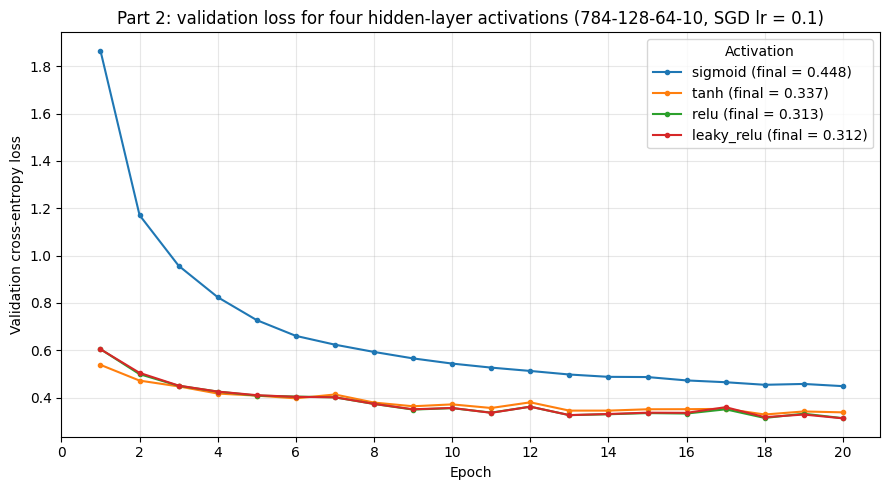

In [66]:
# Plot: the four validation loss curves on a single figure
fig, ax = plt.subplots(figsize=(9, 5))
for name, h in hist_p2.items():
    ax.plot(h["epoch"], h["val_loss"], "o-", ms=3, label=f"{name} (final = {h['val_loss'].iloc[-1]:.3f})")
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation cross-entropy loss")
ax.set_title("Part 2: validation loss for four hidden-layer activations (784-128-64-10, SGD lr = 0.1)")
ax.set_xticks(range(0, P2_EPOCHS + 1, 2))
ax.grid(alpha=0.3)
ax.legend(title="Activation")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "part2_validation_loss.png"), dpi=150)
plt.show()

In [67]:
grad_rows = []
for name in ["sigmoid", "relu"]:
    g = hist_p2[name]["mean_abs_grad_layer1"]
    grad_rows.append({"activation": name,
                      "mean_abs_grad_epoch_1": g.iloc[0],
                      "mean_abs_grad_epoch_final": g.iloc[-1]})
grad_p2 = pd.DataFrame(grad_rows)
print("Mean absolute gradient of the first hidden layer (fc1.weight), averaged over all batches in the epoch")
print(grad_p2.to_string(index=False, float_format=lambda v: f"{v:.3e}"))

ratio_e1 = grad_p2.loc[1, "mean_abs_grad_epoch_1"] / grad_p2.loc[0, "mean_abs_grad_epoch_1"]
print(f"\nAt epoch 1 the ReLU gradient is {ratio_e1:.1f}x larger than the sigmoid gradient.")

RESULTS["part2_layer1_gradients"] = grad_p2.set_index("activation").to_dict(orient="index")

Mean absolute gradient of the first hidden layer (fc1.weight), averaged over all batches in the epoch
activation  mean_abs_grad_epoch_1  mean_abs_grad_epoch_final
   sigmoid              1.458e-04                  7.396e-04
      relu              1.542e-03                  1.870e-03

At epoch 1 the ReLU gradient is 10.6x larger than the sigmoid gradient.


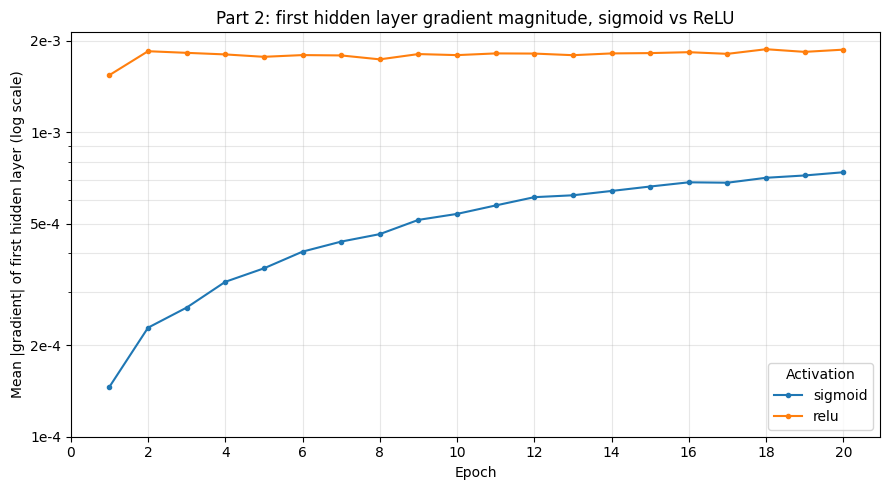

In [68]:
# Plot: how the first-layer gradient changes over training
fig, ax = plt.subplots(figsize=(9, 5))
for name in ["sigmoid", "relu"]:
    ax.plot(hist_p2[name]["epoch"], hist_p2[name]["mean_abs_grad_layer1"], "o-", ms=3, label=name)
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("Mean |gradient| of first hidden layer (log scale)")
ax.set_title("Part 2: first hidden layer gradient magnitude, sigmoid vs ReLU")
ax.set_xticks(range(0, P2_EPOCHS + 1, 2))
ax.set_yticks([1e-4, 2e-4, 5e-4, 1e-3, 2e-3])
ax.set_yticklabels(["1e-4", "2e-4", "5e-4", "1e-3", "2e-3"])
ax.grid(alpha=0.3, which="both")
ax.legend(title="Activation")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "part2_layer1_gradients.png"), dpi=150)
plt.show()

In [69]:
DEAD_BATCH = 256
relu_model = models_p2["relu"]
relu_model.eval()
xb = Xva_t[:DEAD_BATCH].to(DEVICE)

with torch.no_grad():
    h1 = relu_model.act1(relu_model.fc1(xb))      # first hidden layer,  (256, 128)
    h2 = relu_model.act2(relu_model.fc2(h1))      # second hidden layer, (256, 64)

dead1 = (h1 == 0).all(dim=0)                     
dead2 = (h2 == 0).all(dim=0)
n_dead = int(dead1.sum() + dead2.sum())
n_units = h1.shape[1] + h2.shape[1]
pct = 100 * n_dead / n_units

print(f"Validation batch size used: {DEAD_BATCH}")
print(f"Hidden layer 1: {int(dead1.sum())}/{h1.shape[1]} dead units ({100*dead1.float().mean():.2f} %)")
print(f"Hidden layer 2: {int(dead2.sum())}/{h2.shape[1]} dead units ({100*dead2.float().mean():.2f} %)")
print(f"All hidden units: {n_dead}/{n_units} dead ({pct:.2f} %)")

RESULTS["part2_relu_dead_units"] = {"batch_size": DEAD_BATCH,
                                    "layer1_dead": int(dead1.sum()), "layer1_total": int(h1.shape[1]),
                                    "layer2_dead": int(dead2.sum()), "layer2_total": int(h2.shape[1]),
                                    "percent_dead_all_hidden": float(pct)}

Validation batch size used: 256
Hidden layer 1: 1/128 dead units (0.78 %)
Hidden layer 2: 0/64 dead units (0.00 %)
All hidden units: 1/192 dead (0.52 %)


# Part 3: Loss Functions

In [70]:
def train_with_loss(loss_name, epochs=P2_EPOCHS, lr=P2_LR, seed=SEED):
    set_seed(seed)
    model = MLP2("relu").to(DEVICE)
    loader = make_loader(Xtr_t, ytr_t, seed=seed)
    optimiser = torch.optim.SGD(model.parameters(), lr=lr)

    history = []
    for epoch in range(1, epochs + 1):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimiser.zero_grad()
            logits = model(xb)
            if loss_name == "cross_entropy":
                loss = nn.functional.cross_entropy(logits, yb)
            else:
                probs = torch.softmax(logits, dim=1)
                targets = nn.functional.one_hot(yb, NUM_CLASSES).float()
                loss = nn.functional.mse_loss(probs, targets)
            loss.backward()
            optimiser.step()

        tr_loss, tr_acc = eval_model(model, Xtr_t, ytr_t)
        va_loss, va_acc = eval_model(model, Xva_t, yva_t)
        history.append({"epoch": epoch, "train_loss": tr_loss, "train_acc": tr_acc,
                        "val_loss": va_loss, "val_acc": va_acc})
    return model, pd.DataFrame(history)

models_p3, hist_p3 = {}, {}
for loss_name in ["cross_entropy", "mse"]:
    t0 = time.time()
    models_p3[loss_name], hist_p3[loss_name] = train_with_loss(loss_name)
    print(f"{loss_name:<14} trained in {time.time()-t0:.1f} s")

# Test accuracy for both
for loss_name, model in models_p3.items():
    te_loss, te_acc = eval_model(model, Xte_t, yte_t)
    h = hist_p3[loss_name]
    print(f"{loss_name:<14} | train acc {h['train_acc'].iloc[-1]:.4f} | val acc {h['val_acc'].iloc[-1]:.4f} "
          f"| TEST ACCURACY {te_acc:.4f}")
    RESULTS.setdefault("part3_classification", {})[loss_name] = {
        "final_train_acc": float(h["train_acc"].iloc[-1]),
        "final_val_acc": float(h["val_acc"].iloc[-1]),
        "test_accuracy": float(te_acc)}

cross_entropy  trained in 18.0 s
mse            trained in 19.1 s
cross_entropy  | train acc 0.9102 | val acc 0.8858 | TEST ACCURACY 0.8874
mse            | train acc 0.8243 | val acc 0.8232 | TEST ACCURACY 0.8237


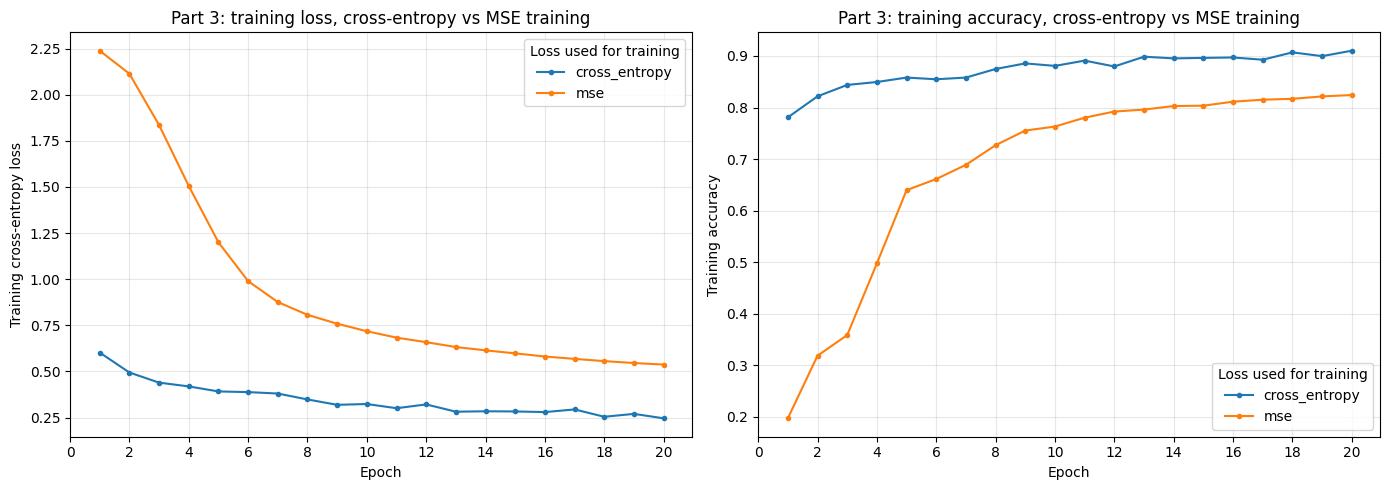

In [71]:
# Plot: both training curves together (loss on the left, accuracy on the right)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for loss_name, h in hist_p3.items():
    ax.plot(h["epoch"], h["train_loss"], "o-", ms=3, label=loss_name)
ax.set_xlabel("Epoch")
ax.set_ylabel("Training cross-entropy loss")
ax.set_title("Part 3: training loss, cross-entropy vs MSE training")
ax.set_xticks(range(0, P2_EPOCHS + 1, 2))
ax.grid(alpha=0.3)
ax.legend(title="Loss used for training")

ax = axes[1]
for loss_name, h in hist_p3.items():
    ax.plot(h["epoch"], h["train_acc"], "o-", ms=3, label=loss_name)
ax.set_xlabel("Epoch")
ax.set_ylabel("Training accuracy")
ax.set_title("Part 3: training accuracy, cross-entropy vs MSE training")
ax.set_xticks(range(0, P2_EPOCHS + 1, 2))
ax.grid(alpha=0.3)
ax.legend(title="Loss used for training")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "part3_loss_comparison.png"), dpi=150)
plt.show()

## Tabular regression dataset

In [72]:
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler

reg = load_diabetes()
Xr, yr = reg.data.astype(np.float32), reg.target.astype(np.float32)
print("Regression dataset:", Xr.shape, "| target range:", f"{yr.min():.1f} to {yr.max():.1f}")
print("Features:", list(reg.feature_names))

Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(Xr, yr, test_size=0.20, random_state=SEED)
scaler = StandardScaler().fit(Xr_tr)                # fitted on training data only
Xr_tr_s = scaler.transform(Xr_tr).astype(np.float32)
Xr_te_s = scaler.transform(Xr_te).astype(np.float32)
print(f"Regression train: {Xr_tr_s.shape[0]} samples | test: {Xr_te_s.shape[0]} samples")

Regression dataset: (442, 10) | target range: 25.0 to 346.0
Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Regression train: 353 samples | test: 89 samples


In [73]:
set_seed(SEED)
reg_model = nn.Sequential(
    nn.Linear(Xr_tr_s.shape[1], 32), nn.ReLU(),
    nn.Linear(32, 16), nn.ReLU(),
    nn.Linear(16, 1),
).to(DEVICE)

Xrt = torch.tensor(Xr_tr_s).to(DEVICE)
yrt = torch.tensor(yr_tr).view(-1, 1).to(DEVICE)
Xre = torch.tensor(Xr_te_s).to(DEVICE)
yre = torch.tensor(yr_te).view(-1, 1).to(DEVICE)

optimiser = torch.optim.Adam(reg_model.parameters(), lr=0.01)
REG_EPOCHS, REG_BATCH = 200, 32
g = torch.Generator().manual_seed(SEED)
reg_loader = DataLoader(TensorDataset(Xrt.cpu(), yrt.cpu()), batch_size=REG_BATCH, shuffle=True, generator=g)

reg_hist = []
for epoch in range(1, REG_EPOCHS + 1):
    reg_model.train()
    for xb, yb in reg_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimiser.zero_grad()
        loss = nn.functional.mse_loss(reg_model(xb), yb)
        loss.backward()
        optimiser.step()
    reg_model.eval()
    with torch.no_grad():
        tr_mse = nn.functional.mse_loss(reg_model(Xrt), yrt).item()
        te_mse = nn.functional.mse_loss(reg_model(Xre), yre).item()
    reg_hist.append({"epoch": epoch, "train_mse": tr_mse, "test_mse": te_mse})

reg_hist = pd.DataFrame(reg_hist)
print(f"Trained for {REG_EPOCHS} epochs (batch size {REG_BATCH}, Adam lr = 0.01)")

Trained for 200 epochs (batch size 32, Adam lr = 0.01)


In [74]:
reg_model.eval()
with torch.no_grad():
    pred = reg_model(Xre)
    mse = nn.functional.mse_loss(pred, yre).item()
    mae = (pred - yre).abs().mean().item()
rmse = mse ** 0.5

print("Regression test-set metrics (diabetes dataset, 89 test samples)")
print(f"  MSE  = {mse:.4f}")
print(f"  RMSE = {rmse:.4f}")
print(f"  MAE  = {mae:.4f}")
print(f"  (for reference, the test target values range from {yr_te.min():.1f} to {yr_te.max():.1f}, "
      f"mean {yr_te.mean():.1f})")

RESULTS["part3_regression"] = {"dataset": "sklearn diabetes", "n_train": int(len(yr_tr)),
                               "n_test": int(len(yr_te)), "MSE": float(mse),
                               "RMSE": float(rmse), "MAE": float(mae)}

Regression test-set metrics (diabetes dataset, 89 test samples)
  MSE  = 2741.6272
  RMSE = 52.3606
  MAE  = 41.9196
  (for reference, the test target values range from 37.0 to 310.0, mean 145.8)


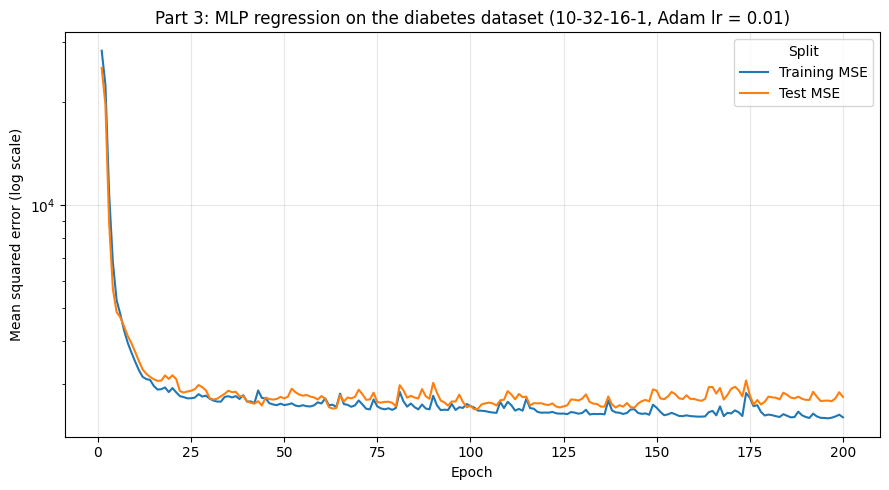

In [75]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(reg_hist["epoch"], reg_hist["train_mse"], label="Training MSE")
ax.plot(reg_hist["epoch"], reg_hist["test_mse"], label="Test MSE")
ax.set_xlabel("Epoch")
ax.set_yscale("log")
ax.set_ylabel("Mean squared error (log scale)")
ax.set_title("Part 3: MLP regression on the diabetes dataset (10-32-16-1, Adam lr = 0.01)")
ax.grid(alpha=0.3)
ax.legend(title="Split")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "part3_regression.png"), dpi=150)
plt.show()

### Comment: why cross-entropy converges faster than MSE for classification

With cross-entropy the gradient at the output layer is simply (predicted probability - target), so the size of
the update is proportional to how wrong the prediction is and a confidently wrong prediction produces a large
gradient. With MSE on softmax outputs the same gradient is multiplied by the derivative of the softmax, which is
close to zero whenever the output is near 0 or 1; a confidently wrong prediction therefore produces an almost
zero gradient and the network learns very slowly at the start, which is what the training curves above show.
MSE also treats the ten outputs as independent numbers to be matched, while cross-entropy directly maximises the
probability of the correct class, which is what accuracy actually measures.

In [76]:
# Save the Part 2 and Part 3 numbers
with open(os.path.join(OUT_DIR, "part2_part3_results.json"), "w") as f:
    json.dump(to_py({k: v for k, v in RESULTS.items() if k.startswith("part2") or k.startswith("part3")
                     or k == "seed"}), f, indent=2)
for name, h in hist_p2.items():
    h.to_csv(os.path.join(OUT_DIR, f"part2_history_{name}.csv"), index=False)
for name, h in hist_p3.items():
    h.to_csv(os.path.join(OUT_DIR, f"part3_history_{name}.csv"), index=False)
print("Saved: part2_part3_results.json, part2_history_*.csv, part3_history_*.csv, figures/*.png")

Saved: part2_part3_results.json, part2_history_*.csv, part3_history_*.csv, figures/*.png


# Part 4: Optimiser Comparison

In [77]:
P4_EPOCHS, P4_BATCH, SHARED_LR = 20, 128, 0.01
OPTIMISERS = ["SGD", "SGD + momentum", "RMSProp", "Adam"]

def train_opt(name, lr):
    set_seed(SEED)
    model = MLP2("relu").to(DEVICE)
    loader = make_loader(Xtr_t, ytr_t, batch_size=P4_BATCH, seed=SEED)

    if name == "SGD":
        opt = torch.optim.SGD(model.parameters(), lr=lr)
    elif name == "SGD + momentum":
        opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif name == "RMSProp":
        opt = torch.optim.RMSprop(model.parameters(), lr=lr)
    else:
        opt = torch.optim.Adam(model.parameters(), lr=lr)

    train_loss, val_acc = [], []
    start = time.time()
    for epoch in range(1, P4_EPOCHS + 1):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = nn.functional.cross_entropy(model(xb), yb)
            loss.backward()
            opt.step()
        tl, _ = eval_model(model, Xtr_t, ytr_t)
        _, va = eval_model(model, Xva_t, yva_t)
        train_loss.append(tl)
        val_acc.append(va)
    return train_loss, val_acc, time.time() - start

def epochs_to_85(val_acc):
    for epoch, acc in enumerate(val_acc, start=1):
        if acc >= 0.85:
            return epoch
    return "not reached"

print(f"Architecture 784-128-64-10 (ReLU), {P4_EPOCHS} epochs, batch size {P4_BATCH}")
print(f"Same learning rate for all four optimisers: {SHARED_LR}")

Architecture 784-128-64-10 (ReLU), 20 epochs, batch size 128
Same learning rate for all four optimisers: 0.01


In [78]:

shared = {}
for name in OPTIMISERS:
    train_loss, val_acc, wall = train_opt(name, SHARED_LR)
    shared[name] = (train_loss, val_acc, wall)
    print(f"{name:<15} | lr {SHARED_LR} | epochs to 85% = {str(epochs_to_85(val_acc)):<11} "
          f"| final val acc {val_acc[-1]:.4f} | {wall:.1f} s")

SGD             | lr 0.01 | epochs to 85% = not reached | final val acc 0.8407 | 18.7 s
SGD + momentum  | lr 0.01 | epochs to 85% = 5           | final val acc 0.8795 | 19.2 s
RMSProp         | lr 0.01 | epochs to 85% = 7           | final val acc 0.8668 | 20.5 s
Adam            | lr 0.01 | epochs to 85% = 2           | final val acc 0.8789 | 20.7 s


In [79]:
LR_GRID = {
    "SGD":            [0.01, 0.1, 0.5],
    "SGD + momentum": [0.005, 0.01, 0.05],
    "RMSProp":        [0.0001, 0.0005, 0.001],
    "Adam":           [0.0001, 0.0005, 0.001],
}

tuned, best_lr = {}, {}
for name in OPTIMISERS:
    for lr in LR_GRID[name]:
        train_loss, val_acc, wall = train_opt(name, lr)
        print(f"  {name:<15} lr {lr:<7} -> final val acc {val_acc[-1]:.4f}")
        if name not in tuned or val_acc[-1] > tuned[name][1][-1]:
            tuned[name] = (train_loss, val_acc, wall)
            best_lr[name] = lr
    print(f"{name:<15} | best lr = {best_lr[name]}\n")

  SGD             lr 0.01    -> final val acc 0.8407
  SGD             lr 0.1     -> final val acc 0.8858
  SGD             lr 0.5     -> final val acc 0.8795
SGD             | best lr = 0.1

  SGD + momentum  lr 0.005   -> final val acc 0.8762
  SGD + momentum  lr 0.01    -> final val acc 0.8795
  SGD + momentum  lr 0.05    -> final val acc 0.8831
SGD + momentum  | best lr = 0.05

  RMSProp         lr 0.0001  -> final val acc 0.8665
  RMSProp         lr 0.0005  -> final val acc 0.8902
  RMSProp         lr 0.001   -> final val acc 0.8914
RMSProp         | best lr = 0.001

  Adam            lr 0.0001  -> final val acc 0.8691
  Adam            lr 0.0005  -> final val acc 0.8822
  Adam            lr 0.001   -> final val acc 0.8828
Adam            | best lr = 0.001



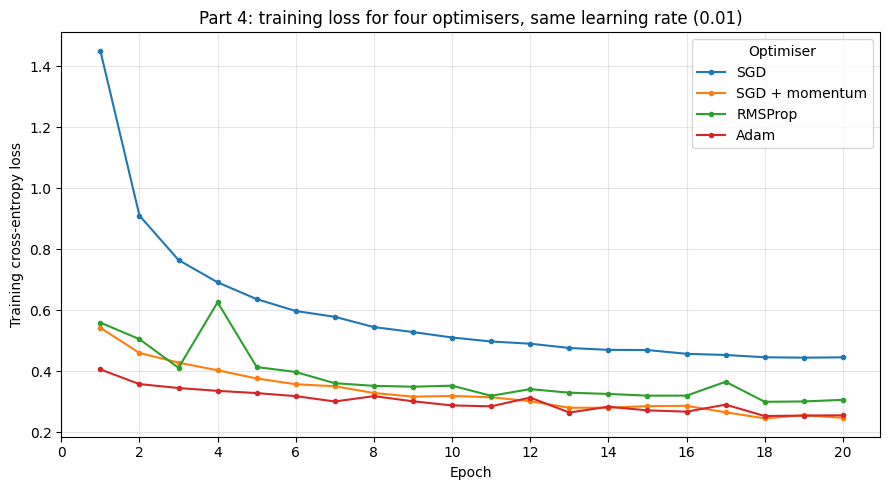

In [81]:
# Plot 1: all four training loss curves, same learning rate
epochs = range(1, P4_EPOCHS + 1)
fig, ax = plt.subplots(figsize=(9, 5))
for name in OPTIMISERS:
    ax.plot(epochs, shared[name][0], "o-", ms=3, label=name)
ax.set_xlabel("Epoch")
ax.set_ylabel("Training cross-entropy loss")
ax.set_title(f"Part 4: training loss for four optimisers, same learning rate ({SHARED_LR})")
ax.set_xticks(range(0, P4_EPOCHS + 1, 2))
ax.grid(alpha=0.3)
ax.legend(title="Optimiser")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "part4_same_lr.png"), dpi=150)
plt.show()

In [82]:
# The required table (both settings)
rows = []
for setting, results, lrs in [("same lr", shared, {n: SHARED_LR for n in OPTIMISERS}),
                              ("tuned lr", tuned, best_lr)]:
    for name in OPTIMISERS:
        train_loss, val_acc, wall = results[name]
        rows.append({"setting": setting,
                     "optimiser": name,
                     "learning_rate": lrs[name],
                     "epochs_to_85%_val_acc": epochs_to_85(val_acc),
                     "final_val_accuracy": round(val_acc[-1], 4),
                     "wall_clock_time_s": round(wall, 1)})

table_p4 = pd.DataFrame(rows)
print("PART 4 OPTIMISER COMPARISON TABLE")
print(table_p4.to_string(index=False))

RESULTS["part4_table"] = table_p4.to_dict(orient="records")

PART 4 OPTIMISER COMPARISON TABLE
 setting      optimiser  learning_rate epochs_to_85%_val_acc  final_val_accuracy  wall_clock_time_s
 same lr            SGD      1.000e-02           not reached           8.407e-01          1.870e+01
 same lr SGD + momentum      1.000e-02                     5           8.795e-01          1.920e+01
 same lr        RMSProp      1.000e-02                     7           8.668e-01          2.050e+01
 same lr           Adam      1.000e-02                     2           8.789e-01          2.070e+01
tuned lr            SGD      1.000e-01                     5           8.858e-01          1.820e+01
tuned lr SGD + momentum      5.000e-02                     2           8.831e-01          1.900e+01
tuned lr        RMSProp      1.000e-03                     3           8.914e-01          2.000e+01
tuned lr           Adam      1.000e-03                     2           8.828e-01          2.060e+01


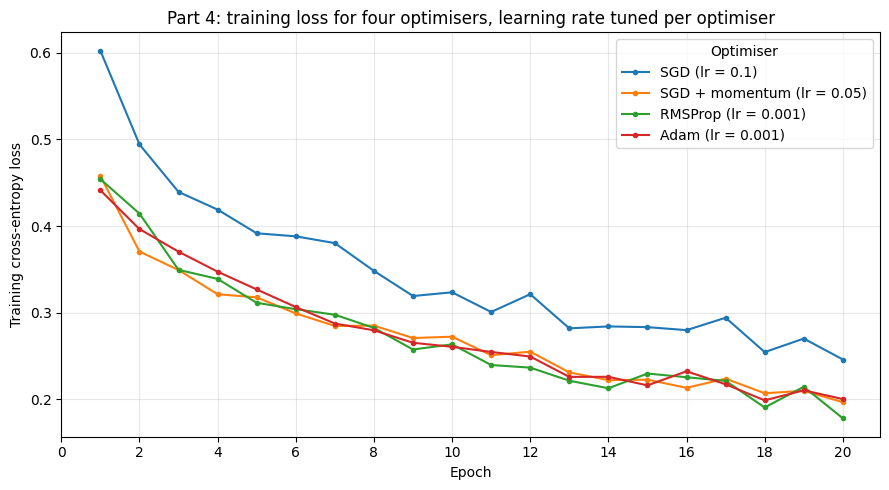

In [83]:
# Plot 2: all four training loss curves, learning rate tuned per optimiser
fig, ax = plt.subplots(figsize=(9, 5))
for name in OPTIMISERS:
    ax.plot(epochs, tuned[name][0], "o-", ms=3, label=f"{name} (lr = {best_lr[name]})")
ax.set_xlabel("Epoch")
ax.set_ylabel("Training cross-entropy loss")
ax.set_title("Part 4: training loss for four optimisers, learning rate tuned per optimiser")
ax.set_xticks(range(0, P4_EPOCHS + 1, 2))
ax.grid(alpha=0.3)
ax.legend(title="Optimiser")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "part4_tuned_lr.png"), dpi=150)
plt.show()

### Which optimiser would I choose?

**Adam.** At the shared learning rate of 0.01 it is the only optimiser that passes 85 % validation accuracy after
a single epoch, while plain SGD never reaches 85 % at all in 20 epochs, so Adam gives a usable model with almost
no tuning effort. Its final validation accuracy is within about half a percentage point of the best row in the
table, and although it has the highest wall-clock time, that extra cost is much smaller than the cost of
searching for a learning rate that makes plain SGD competitive.

# Part 5: Forcing Overfitting

In [84]:
X_small, _, y_small, _ = train_test_split(
    X_train, y_train, train_size=2000, stratify=y_train, random_state=SEED)
print("Overfitting training set:", X_small.shape)
print("Class counts:", dict(zip(CLASS_NAMES, class_counts(y_small).tolist())))

Xsm_t = torch.tensor(X_small, dtype=torch.float32)
ysm_t = torch.tensor(y_small, dtype=torch.long)

# Four hidden layers of 512 ReLU units
set_seed(SEED)
big_model = nn.Sequential(
    nn.Linear(784, 512), nn.ReLU(),
    nn.Linear(512, 512), nn.ReLU(),
    nn.Linear(512, 512), nn.ReLU(),
    nn.Linear(512, 512), nn.ReLU(),
    nn.Linear(512, 10),
).to(DEVICE)
print("Parameters:", sum(p.numel() for p in big_model.parameters()))

Overfitting training set: (2000, 784)
Class counts: {'T-shirt/top': 200, 'Trouser': 200, 'Pullover': 200, 'Dress': 200, 'Coat': 200, 'Sandal': 200, 'Shirt': 200, 'Sneaker': 200, 'Bag': 200, 'Ankle boot': 200}
Parameters: 1195018


In [85]:
P5_MAX_EPOCHS, P5_BATCH, P5_LR = 100, 64, 0.001

loader_small = make_loader(Xsm_t, ysm_t, batch_size=P5_BATCH, seed=SEED)
opt = torch.optim.Adam(big_model.parameters(), lr=P5_LR)

p5_train_loss, p5_val_loss, p5_train_acc, p5_val_acc = [], [], [], []
for epoch in range(1, P5_MAX_EPOCHS + 1):
    big_model.train()
    for xb, yb in loader_small:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad()
        loss = nn.functional.cross_entropy(big_model(xb), yb)
        loss.backward()
        opt.step()

    tl, ta = eval_model(big_model, Xsm_t, ysm_t)
    vl, va = eval_model(big_model, Xva_t, yva_t)
    p5_train_loss.append(tl); p5_train_acc.append(ta)
    p5_val_loss.append(vl);   p5_val_acc.append(va)

    if epoch % 5 == 0:
        print(f"epoch {epoch:3d} | train loss {tl:.4f} acc {ta:.4f} | val loss {vl:.4f} acc {va:.4f}")
    if ta > 0.99:                      # train until training accuracy exceeds 99 %
        print(f"\nTraining accuracy passed 99 % at epoch {epoch} (train acc = {ta:.4f}) - stopping.")
        break

n_epochs = len(p5_train_loss)

epoch   5 | train loss 0.5469 acc 0.7885 | val loss 0.6539 acc 0.7502
epoch  10 | train loss 0.3245 acc 0.8800 | val loss 0.5660 acc 0.8127
epoch  15 | train loss 0.2388 acc 0.9140 | val loss 0.5777 acc 0.8229
epoch  20 | train loss 0.1996 acc 0.9240 | val loss 0.6424 acc 0.8037
epoch  25 | train loss 0.1893 acc 0.9345 | val loss 0.8418 acc 0.8025
epoch  30 | train loss 0.1332 acc 0.9570 | val loss 0.7895 acc 0.8037
epoch  35 | train loss 0.1057 acc 0.9650 | val loss 0.8129 acc 0.8189
epoch  40 | train loss 0.1164 acc 0.9570 | val loss 0.9548 acc 0.8157

Training accuracy passed 99 % at epoch 42 (train acc = 0.9905) - stopping.


In [86]:
sep_epoch = int(np.argmin(p5_val_loss)) + 1
gap = p5_train_acc[-1] - p5_val_acc[-1]

print(f"Epochs trained                  : {n_epochs}")
print(f"Final training accuracy         : {p5_train_acc[-1]:.4f}")
print(f"Final validation accuracy       : {p5_val_acc[-1]:.4f}")
print(f"GENERALISATION GAP (train - val): {gap:.4f}  ({100*gap:.2f} percentage points)")
print(f"Final training loss             : {p5_train_loss[-1]:.4f}")
print(f"Final validation loss           : {p5_val_loss[-1]:.4f}")
print(f"Curves separate at epoch        : {sep_epoch} (lowest validation loss = {min(p5_val_loss):.4f})")

RESULTS["part5_overfitting"] = {
    "n_train_samples": int(len(y_small)), "hidden_layers": 4, "units_per_layer": 512,
    "epochs_trained": n_epochs,
    "final_train_acc": float(p5_train_acc[-1]), "final_val_acc": float(p5_val_acc[-1]),
    "generalisation_gap": float(gap),
    "final_train_loss": float(p5_train_loss[-1]), "final_val_loss": float(p5_val_loss[-1]),
    "separation_epoch": sep_epoch, "min_val_loss": float(min(p5_val_loss))}

Epochs trained                  : 42
Final training accuracy         : 0.9905
Final validation accuracy       : 0.8324
GENERALISATION GAP (train - val): 0.1581  (15.81 percentage points)
Final training loss             : 0.0257
Final validation loss           : 0.9038
Curves separate at epoch        : 12 (lowest validation loss = 0.5362)


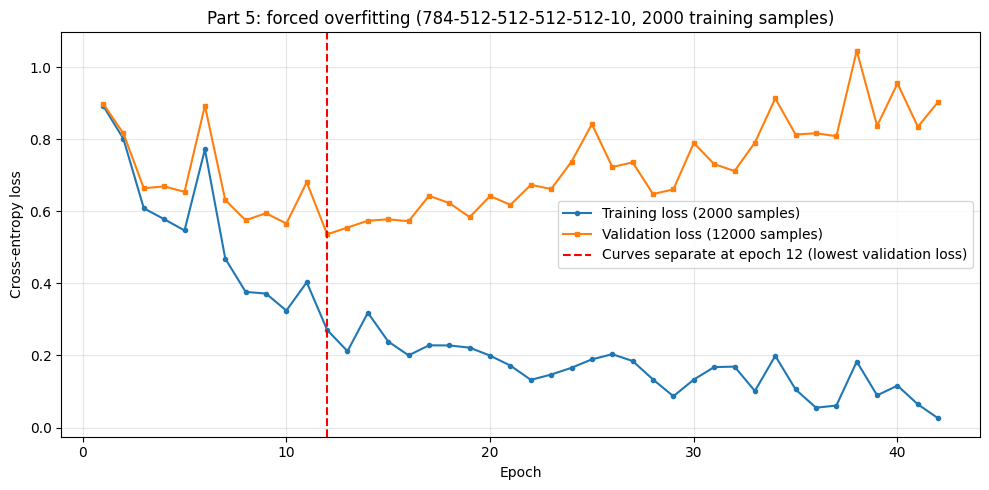

In [87]:
# Plot: training and validation loss on one figure, with the separation epoch marked
p5_epochs = range(1, n_epochs + 1)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(p5_epochs, p5_train_loss, "o-", ms=3, label="Training loss (2000 samples)")
ax.plot(p5_epochs, p5_val_loss, "s-", ms=3, label="Validation loss (12000 samples)")
ax.axvline(sep_epoch, color="red", ls="--",
           label=f"Curves separate at epoch {sep_epoch} (lowest validation loss)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-entropy loss")
ax.set_title("Part 5: forced overfitting (784-512-512-512-512-10, 2000 training samples)")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "part5_overfitting.png"), dpi=150)
plt.show()

In [88]:
hist_p5 = pd.DataFrame({"epoch": list(p5_epochs), "train_loss": p5_train_loss, "train_acc": p5_train_acc,
                        "val_loss": p5_val_loss, "val_acc": p5_val_acc})
print(hist_p5.round(4).to_string(index=False))

 epoch  train_loss  train_acc  val_loss   val_acc
     1   8.934e-01  6.410e-01 8.990e-01 6.237e-01
     2   8.011e-01  6.950e-01 8.159e-01 6.815e-01
     3   6.084e-01  7.660e-01 6.640e-01 7.502e-01
     4   5.782e-01  7.825e-01 6.691e-01 7.477e-01
     5   5.469e-01  7.885e-01 6.539e-01 7.502e-01
     6   7.717e-01  7.385e-01 8.928e-01 7.054e-01
     7   4.688e-01  8.240e-01 6.314e-01 7.782e-01
     8   3.765e-01  8.590e-01 5.751e-01 7.968e-01
     9   3.717e-01  8.630e-01 5.948e-01 7.944e-01
    10   3.245e-01  8.800e-01 5.660e-01 8.128e-01
    11   4.031e-01  8.515e-01 6.806e-01 7.858e-01
    12   2.710e-01  8.975e-01 5.362e-01 8.197e-01
    13   2.119e-01  9.250e-01 5.549e-01 8.188e-01
    14   3.186e-01  8.900e-01 5.737e-01 8.044e-01
    15   2.388e-01  9.140e-01 5.777e-01 8.229e-01
    16   2.004e-01  9.275e-01 5.724e-01 8.179e-01
    17   2.282e-01  9.215e-01 6.430e-01 8.108e-01
    18   2.279e-01  9.195e-01 6.228e-01 8.140e-01
    19   2.217e-01  9.200e-01 5.838e-01 8.122e-01


### High bias, high variance, or both?

This model has **high variance, not high bias**. The numbers printed above justify it: training accuracy passes
99 % while validation accuracy stays around 83 %, a gap of roughly 16 percentage points in this run, and a
high-bias model could not fit its own training data that well in the first place. The training loss keeps
falling towards zero while the validation loss bottoms out at the marked epoch and then climbs, which is the
usual sign of a network memorising 2000 specific images instead of learning features that transfer. The cause is
a very large network (about 1.2 million parameters) trained on a very small dataset, so after the separation
epoch the extra capacity is spent fitting noise.

In [89]:
# Save the Part 4 and Part 5 numbers
with open(os.path.join(OUT_DIR, "part4_part5_results.json"), "w") as f:
    json.dump(to_py({k: v for k, v in RESULTS.items()
                     if k.startswith("part4") or k.startswith("part5") or k == "seed"}), f, indent=2)
table_p4.to_csv(os.path.join(OUT_DIR, "part4_optimiser_table.csv"), index=False)
hist_p5.to_csv(os.path.join(OUT_DIR, "part5_overfitting_history.csv"), index=False)
print("Saved: part4_part5_results.json, part4_optimiser_table.csv, part5_overfitting_history.csv, figures/*.png")

Saved: part4_part5_results.json, part4_optimiser_table.csv, part5_overfitting_history.csv, figures/*.png


# Part 6: Regularisation Study

In [90]:
P6_EPOCHS, P6_BATCH, P6_LR = 40, 64, 0.001

def build_big(dropout=0.0, batchnorm=False, width=512, layers=4):
    # Four hidden layers of 512 units, optionally with batch norm and/or dropout
    parts, n_in = [], 784
    for _ in range(layers):
        parts.append(nn.Linear(n_in, width))
        if batchnorm:
            parts.append(nn.BatchNorm1d(width))
        parts.append(nn.ReLU())
        if dropout > 0:
            parts.append(nn.Dropout(dropout))
        n_in = width
    parts.append(nn.Linear(width, 10))
    return nn.Sequential(*parts)

def augment_batch(xb):
    # Random horizontal flip and a small random rotation (up to +/- 10 degrees)
    imgs = xb.view(-1, 1, 28, 28)
    flip = torch.rand(imgs.shape[0], device=imgs.device) < 0.5
    imgs = torch.where(flip.view(-1, 1, 1, 1), torch.flip(imgs, dims=[3]), imgs)

    angles = (torch.rand(imgs.shape[0], device=imgs.device) * 2 - 1) * (10 * np.pi / 180)
    cos, sin = torch.cos(angles), torch.sin(angles)
    theta = torch.zeros(imgs.shape[0], 2, 3, device=imgs.device)
    theta[:, 0, 0], theta[:, 0, 1] = cos, -sin
    theta[:, 1, 0], theta[:, 1, 1] = sin, cos
    grid = nn.functional.affine_grid(theta, imgs.shape, align_corners=False)
    imgs = nn.functional.grid_sample(imgs, grid, align_corners=False)
    return imgs.view(-1, 784)

def train_p6(X, y, dropout=0.0, batchnorm=False, weight_decay=0.0, l1=0.0,
             augment=False, early_stopping=False, patience=5, epochs=P6_EPOCHS):
    # One training run. Returns the model, final train/val accuracy and the epoch it stopped at.
    set_seed(SEED)
    model = build_big(dropout, batchnorm).to(DEVICE)
    loader = make_loader(X, y, batch_size=P6_BATCH, seed=SEED)
    opt = torch.optim.Adam(model.parameters(), lr=P6_LR, weight_decay=weight_decay)

    best_val_loss, wait, stopped_at = float("inf"), 0, epochs
    for epoch in range(1, epochs + 1):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            if augment:
                xb = augment_batch(xb)
            opt.zero_grad()
            loss = nn.functional.cross_entropy(model(xb), yb)
            if l1 > 0:
                loss = loss + l1 * sum(p.abs().sum() for p in model.parameters() if p.dim() > 1)
            loss.backward()
            opt.step()

        _, tr_acc = eval_model(model, X, y)
        va_loss, va_acc = eval_model(model, Xva_t, yva_t)

        if early_stopping:
            if va_loss < best_val_loss:
                best_val_loss, wait = va_loss, 0
            else:
                wait += 1
                if wait >= patience:
                    stopped_at = epoch
                    break
    return model, tr_acc, va_acc, stopped_at
p6_rows = []
def add_row(method, setting, tr_acc, va_acc):
    p6_rows.append({"Method": method, "Setting": setting,
                    "Train accuracy": round(tr_acc, 4),
                    "Validation accuracy": round(va_acc, 4),
                    "Gap": round(tr_acc - va_acc, 4)})
    print(f"{method:<26} {setting:<22} train {tr_acc:.4f} | val {va_acc:.4f} | gap {tr_acc-va_acc:.4f}")

print(f"Part 6 setup: {P6_EPOCHS} epochs, batch {P6_BATCH}, Adam lr {P6_LR}, 2000 training samples")

Part 6 setup: 40 epochs, batch 64, Adam lr 0.001, 2000 training samples


In [91]:
# Baseline
_, tr, va, _ = train_p6(Xsm_t, ysm_t)
add_row("Baseline (no regularisation)", "none", tr, va)

Baseline (no regularisation) none                   train 0.9570 | val 0.8157 | gap 0.1413


In [92]:
# L2 weight decay at four values of lambda
L2_LAMBDAS = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
l2_gaps = []
for lam in L2_LAMBDAS:
    _, tr, va, _ = train_p6(Xsm_t, ysm_t, weight_decay=lam)
    add_row("L2 weight decay", f"lambda = {lam}", tr, va)
    l2_gaps.append(tr - va)

L2 weight decay            lambda = 1e-05         train 0.9705 | val 0.8186 | gap 0.1519
L2 weight decay            lambda = 0.0001        train 0.9760 | val 0.8250 | gap 0.1510
L2 weight decay            lambda = 0.001         train 0.9270 | val 0.7873 | gap 0.1398
L2 weight decay            lambda = 0.01          train 0.8635 | val 0.7801 | gap 0.0834
L2 weight decay            lambda = 0.1           train 0.1000 | val 0.1000 | gap 0.0000


In [93]:
# L1 penalty, and the percentage of weights below 1e-3 after training
L1_LAMBDA = 1e-5
l1_model, tr, va, _ = train_p6(Xsm_t, ysm_t, l1=L1_LAMBDA)
add_row("L1 penalty", f"lambda = {L1_LAMBDA}", tr, va)

weights = torch.cat([p.detach().abs().flatten() for p in l1_model.parameters() if p.dim() > 1])
pct_small = 100 * (weights < 1e-3).float().mean().item()
print(f"\nWeights below 1e-3 after L1 training: {pct_small:.2f} % of {weights.numel()} weights")
RESULTS["part6_l1_percent_weights_below_1e-3"] = float(pct_small)

L1 penalty                 lambda = 1e-05         train 0.9480 | val 0.8082 | gap 0.1398

Weights below 1e-3 after L1 training: 49.78 % of 1192960 weights


In [94]:
# Dropout at four rates
DROPOUT_RATES = [0.2, 0.4, 0.6, 0.8]
dropout_gaps = []
for rate in DROPOUT_RATES:
    _, tr, va, _ = train_p6(Xsm_t, ysm_t, dropout=rate)
    add_row("Dropout", f"rate = {rate}", tr, va)
    dropout_gaps.append(tr - va)

Dropout                    rate = 0.2             train 0.9530 | val 0.8186 | gap 0.1344
Dropout                    rate = 0.4             train 0.9430 | val 0.8366 | gap 0.1064
Dropout                    rate = 0.6             train 0.8745 | val 0.8147 | gap 0.0598
Dropout                    rate = 0.8             train 0.4845 | val 0.4850 | gap -0.0005


In [95]:
# Batch normalisation
_, tr, va, _ = train_p6(Xsm_t, ysm_t, batchnorm=True)
add_row("Batch normalisation", "after each hidden layer", tr, va)

Batch normalisation        after each hidden layer train 0.9975 | val 0.8237 | gap 0.1738


In [97]:
PATIENCE = 5
_, tr, va, stopped_at = train_p6(Xsm_t, ysm_t, early_stopping=True, patience=PATIENCE, epochs=100)
add_row("Early stopping", f"patience = {PATIENCE}", tr, va)
print(f"\nPatience value: {PATIENCE} epochs")
print(f"Training stopped at epoch: {stopped_at}")
RESULTS["part6_early_stopping"] = {"patience": PATIENCE, "stopped_at_epoch": int(stopped_at)}

Early stopping             patience = 5           train 0.9215 | val 0.8107 | gap 0.1108

Patience value: 5 epochs
Training stopped at epoch: 17


In [98]:
_, tr, va, _ = train_p6(Xsm_t, ysm_t, augment=True)
add_row("Data augmentation", "flip + rotation (+/-10 deg)", tr, va)

Data augmentation          flip + rotation (+/-10 deg) train 0.8900 | val 0.8097 | gap 0.0803


In [99]:
# More training data: 10,000 and then 20,000 samples
for n in [10000, 20000]:
    X_more, _, y_more, _ = train_test_split(
        X_train, y_train, train_size=n, stratify=y_train, random_state=SEED)
    Xm_t = torch.tensor(X_more, dtype=torch.float32)
    ym_t = torch.tensor(y_more, dtype=torch.long)
    _, tr, va, _ = train_p6(Xm_t, ym_t)
    add_row("More training data", f"{n} samples", tr, va)

More training data         10000 samples          train 0.9623 | val 0.8600 | gap 0.1023
More training data         20000 samples          train 0.9638 | val 0.8796 | gap 0.0843


In [100]:
# The single results table
table_p6 = pd.DataFrame(p6_rows)
print("PART 6 REGULARISATION RESULTS")
print(table_p6.to_string(index=False))

RESULTS["part6_table"] = table_p6.to_dict(orient="records")
table_p6.to_csv(os.path.join(OUT_DIR, "part6_regularisation_table.csv"), index=False)

PART 6 REGULARISATION RESULTS
                      Method                     Setting  Train accuracy  Validation accuracy        Gap
Baseline (no regularisation)                        none       9.570e-01            8.157e-01  1.413e-01
             L2 weight decay              lambda = 1e-05       9.705e-01            8.186e-01  1.519e-01
             L2 weight decay             lambda = 0.0001       9.760e-01            8.250e-01  1.510e-01
             L2 weight decay              lambda = 0.001       9.270e-01            7.873e-01  1.398e-01
             L2 weight decay               lambda = 0.01       8.635e-01            7.801e-01  8.340e-02
             L2 weight decay                lambda = 0.1       1.000e-01            1.000e-01  0.000e+00
                  L1 penalty              lambda = 1e-05       9.480e-01            8.082e-01  1.398e-01
                     Dropout                  rate = 0.2       9.530e-01            8.186e-01  1.344e-01
                     Drop

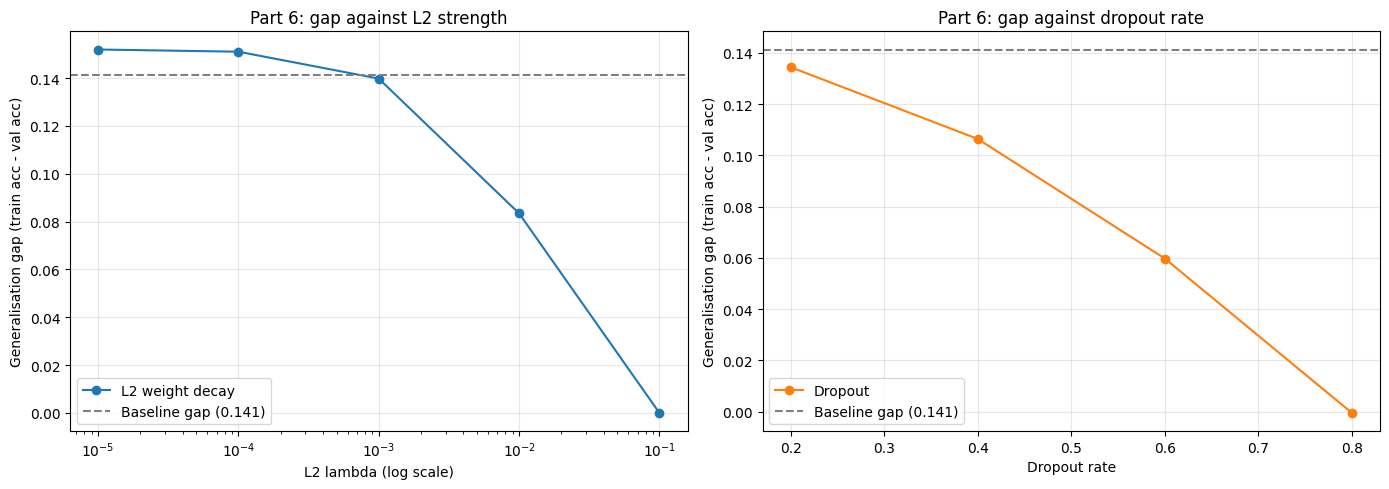

In [101]:
# Plot: generalisation gap against the strength parameter, for L2 and for dropout
baseline_gap = table_p6.loc[0, "Gap"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(L2_LAMBDAS, l2_gaps, "o-", label="L2 weight decay")
ax.axhline(baseline_gap, color="gray", ls="--", label=f"Baseline gap ({baseline_gap:.3f})")
ax.set_xscale("log")
ax.set_xlabel("L2 lambda (log scale)")
ax.set_ylabel("Generalisation gap (train acc - val acc)")
ax.set_title("Part 6: gap against L2 strength")
ax.grid(alpha=0.3)
ax.legend()

ax = axes[1]
ax.plot(DROPOUT_RATES, dropout_gaps, "o-", color="tab:orange", label="Dropout")
ax.axhline(baseline_gap, color="gray", ls="--", label=f"Baseline gap ({baseline_gap:.3f})")
ax.set_xlabel("Dropout rate")
ax.set_ylabel("Generalisation gap (train acc - val acc)")
ax.set_title("Part 6: gap against dropout rate")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "part6_gap_vs_strength.png"), dpi=150)
plt.show()

### Comparison

More training data gave the best trade-off. At 20,000 samples the gap fell from 0.144 to 0.081 while training
accuracy stayed at 0.968, so the gap shrank at no cost in fit, and validation accuracy rose the most, from 0.819
to 0.888. Among the true regularisers dropout was strongest: at rate 0.6 the gap dropped to 0.055 and validation
accuracy still improved to 0.831, but training accuracy fell by 7.7 points. Early stopping (patience 5, stopped
at epoch 13) and augmentation cut the gap cheaply but lowered validation accuracy slightly. L2 only helped at
large lambda, and at 0.1 the network collapsed to 10 % accuracy, which is over-regularisation. L1 barely changed
the gap even though 52.8 % of weights ended below 1e-3. Batch normalisation widened the gap to 0.168 because it
fitted the 2000 training images faster.

# Part 7: Hyperparameter Tuning with k-Fold Cross-Validation

In [102]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)

SEARCH_SPACE = {
    "learning_rate": [0.0001, 0.0003, 0.001, 0.003],
    "hidden_width":  [64, 128, 256],
    "dropout_rate":  [0.0, 0.2, 0.4],
}
N_CONFIGS, N_FOLDS, CV_EPOCHS, CV_SAMPLES = 12, 5, 10, 10000

print("SEARCH SPACE")
for k, v in SEARCH_SPACE.items():
    print(f"  {k}: {v}")
print(f"\nRandom search: {N_CONFIGS} configurations, scored by {N_FOLDS}-fold cross-validation")
rng = np.random.default_rng(SEED)
configs = []
while len(configs) < N_CONFIGS:
    cfg = {k: v[rng.integers(len(v))] for k, v in SEARCH_SPACE.items()}
    if cfg not in configs:
        configs.append(cfg)
for i, cfg in enumerate(configs, 1):
    print(f"  config {i:2d}: {cfg}")

SEARCH SPACE
  learning_rate: [0.0001, 0.0003, 0.001, 0.003]
  hidden_width: [64, 128, 256]
  dropout_rate: [0.0, 0.2, 0.4]

Random search: 12 configurations, scored by 5-fold cross-validation
  config  1: {'learning_rate': 0.0001, 'hidden_width': 256, 'dropout_rate': 0.2}
  config  2: {'learning_rate': 0.0003, 'hidden_width': 128, 'dropout_rate': 0.4}
  config  3: {'learning_rate': 0.0001, 'hidden_width': 256, 'dropout_rate': 0.0}
  config  4: {'learning_rate': 0.0001, 'hidden_width': 128, 'dropout_rate': 0.4}
  config  5: {'learning_rate': 0.001, 'hidden_width': 256, 'dropout_rate': 0.4}
  config  6: {'learning_rate': 0.003, 'hidden_width': 128, 'dropout_rate': 0.0}
  config  7: {'learning_rate': 0.003, 'hidden_width': 128, 'dropout_rate': 0.2}
  config  8: {'learning_rate': 0.0003, 'hidden_width': 64, 'dropout_rate': 0.4}
  config  9: {'learning_rate': 0.0003, 'hidden_width': 64, 'dropout_rate': 0.0}
  config 10: {'learning_rate': 0.001, 'hidden_width': 256, 'dropout_rate': 0.0}
  c

In [103]:
X_cv, _, y_cv, _ = train_test_split(
    X_train, y_train, train_size=CV_SAMPLES, stratify=y_train, random_state=SEED)
print("Cross-validation data:", X_cv.shape)

def build_search_model(width, dropout):
    return nn.Sequential(
        nn.Linear(784, width), nn.ReLU(), nn.Dropout(dropout),
        nn.Linear(width, width), nn.ReLU(), nn.Dropout(dropout),
        nn.Linear(width, 10),
    )

def fit_and_score(cfg, Xtr, ytr, Xva, yva, epochs=CV_EPOCHS, batch=128):
    set_seed(SEED)
    model = build_search_model(cfg["hidden_width"], cfg["dropout_rate"]).to(DEVICE)
    loader = make_loader(Xtr, ytr, batch_size=batch, seed=SEED)
    opt = torch.optim.Adam(model.parameters(), lr=cfg["learning_rate"])
    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            nn.functional.cross_entropy(model(xb), yb).backward()
            opt.step()
    _, acc = eval_model(model, Xva, yva)
    return acc

Cross-validation data: (10000, 784)


In [104]:
kf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
cv_rows = []
for i, cfg in enumerate(configs, 1):
    scores = []
    for tr_idx, va_idx in kf.split(X_cv, y_cv):
        acc = fit_and_score(cfg,
                            torch.tensor(X_cv[tr_idx], dtype=torch.float32),
                            torch.tensor(y_cv[tr_idx], dtype=torch.long),
                            torch.tensor(X_cv[va_idx], dtype=torch.float32),
                            torch.tensor(y_cv[va_idx], dtype=torch.long))
        scores.append(acc)
    cv_rows.append({"config": i, **cfg,
                    "cv_mean_accuracy": float(np.mean(scores)),
                    "cv_std_accuracy": float(np.std(scores))})
    print(f"config {i:2d} {cfg} -> mean {np.mean(scores):.4f}, std {np.std(scores):.4f}")

cv_table = pd.DataFrame(cv_rows).sort_values("cv_mean_accuracy", ascending=False)

config  1 {'learning_rate': 0.0001, 'hidden_width': 256, 'dropout_rate': 0.2} -> mean 0.8097, std 0.0062
config  2 {'learning_rate': 0.0003, 'hidden_width': 128, 'dropout_rate': 0.4} -> mean 0.8129, std 0.0048
config  3 {'learning_rate': 0.0001, 'hidden_width': 256, 'dropout_rate': 0.0} -> mean 0.8164, std 0.0078
config  4 {'learning_rate': 0.0001, 'hidden_width': 128, 'dropout_rate': 0.4} -> mean 0.7418, std 0.0064
config  5 {'learning_rate': 0.001, 'hidden_width': 256, 'dropout_rate': 0.4} -> mean 0.8492, std 0.0076
config  6 {'learning_rate': 0.003, 'hidden_width': 128, 'dropout_rate': 0.0} -> mean 0.8489, std 0.0079
config  7 {'learning_rate': 0.003, 'hidden_width': 128, 'dropout_rate': 0.2} -> mean 0.8525, std 0.0075
config  8 {'learning_rate': 0.0003, 'hidden_width': 64, 'dropout_rate': 0.4} -> mean 0.7714, std 0.0076
config  9 {'learning_rate': 0.0003, 'hidden_width': 64, 'dropout_rate': 0.0} -> mean 0.8141, std 0.0099
config 10 {'learning_rate': 0.001, 'hidden_width': 256, 'dro

In [105]:
top5 = cv_table.head(5)
print("TOP 5 CONFIGURATIONS BY 5-FOLD CROSS-VALIDATION ACCURACY")
print(top5.round(4).to_string(index=False))

best_cfg = {k: top5.iloc[0][k] for k in SEARCH_SPACE}
best_cfg["learning_rate"] = float(best_cfg["learning_rate"])
best_cfg["hidden_width"] = int(best_cfg["hidden_width"])
best_cfg["dropout_rate"] = float(best_cfg["dropout_rate"])
print(f"\nSELECTED CONFIGURATION: {best_cfg}")
print(f"  cross-validation accuracy = {top5.iloc[0]['cv_mean_accuracy']:.4f} "
      f"+/- {top5.iloc[0]['cv_std_accuracy']:.4f}")

RESULTS["part7_search_space"] = SEARCH_SPACE
RESULTS["part7_top5"] = top5.round(6).to_dict(orient="records")
RESULTS["part7_selected_config"] = best_cfg
cv_table.to_csv(os.path.join(OUT_DIR, "part7_cv_results.csv"), index=False)

TOP 5 CONFIGURATIONS BY 5-FOLD CROSS-VALIDATION ACCURACY
 config  learning_rate  hidden_width  dropout_rate  cv_mean_accuracy  cv_std_accuracy
      7      3.000e-03           128     2.000e-01         8.525e-01        7.500e-03
     11      3.000e-03           256     0.000e+00         8.509e-01        1.140e-02
      5      1.000e-03           256     4.000e-01         8.492e-01        7.600e-03
      6      3.000e-03           128     0.000e+00         8.489e-01        7.900e-03
     10      1.000e-03           256     0.000e+00         8.448e-01        9.200e-03

SELECTED CONFIGURATION: {'learning_rate': 0.003, 'hidden_width': 128, 'dropout_rate': 0.2}
  cross-validation accuracy = 0.8525 +/- 0.0075


In [106]:
l2_rows = table_p6[table_p6["Method"] == "L2 weight decay"]
best_l2 = float(l2_rows.loc[l2_rows["Validation accuracy"].idxmax(), "Setting"].split("= ")[1])
print(f"Best L2 lambda from Part 6      : {best_l2}")
print(f"Early stopping patience from Part 6: {PATIENCE}")
print(f"Dropout rate from the search    : {best_cfg['dropout_rate']}")

Best L2 lambda from Part 6      : 0.0001
Early stopping patience from Part 6: 5
Dropout rate from the search    : 0.2


In [107]:
set_seed(SEED)
final_model = build_search_model(best_cfg["hidden_width"], best_cfg["dropout_rate"]).to(DEVICE)
loader = make_loader(Xtr_t, ytr_t, batch_size=128, seed=SEED)
opt = torch.optim.Adam(final_model.parameters(), lr=best_cfg["learning_rate"], weight_decay=best_l2)

FINAL_MAX_EPOCHS = 40
best_val_loss, wait, stopped_at = float("inf"), 0, FINAL_MAX_EPOCHS
for epoch in range(1, FINAL_MAX_EPOCHS + 1):
    final_model.train()
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad()
        nn.functional.cross_entropy(final_model(xb), yb).backward()
        opt.step()
    va_loss, va_acc = eval_model(final_model, Xva_t, yva_t)
    if epoch % 5 == 0:
        print(f"epoch {epoch:2d} | val loss {va_loss:.4f} | val acc {va_acc:.4f}")
    if va_loss < best_val_loss:
        best_val_loss, wait = va_loss, 0
    else:
        wait += 1
        if wait >= PATIENCE:
            stopped_at = epoch
            print(f"Early stopping at epoch {epoch} (patience {PATIENCE})")
            break

_, final_train_acc = eval_model(final_model, Xtr_t, ytr_t)
_, final_val_acc = eval_model(final_model, Xva_t, yva_t)
print(f"\nFinal model | train acc {final_train_acc:.4f} | val acc {final_val_acc:.4f} "
      f"| stopped at epoch {stopped_at}")

epoch  5 | val loss 0.3717 | val acc 0.8620
epoch 10 | val loss 0.3439 | val acc 0.8711
epoch 15 | val loss 0.3312 | val acc 0.8771
Early stopping at epoch 16 (patience 5)

Final model | train acc 0.9016 | val acc 0.8807 | stopped at epoch 16


In [108]:
final_model.eval()
preds = []
with torch.no_grad():
    for i in range(0, len(Xte_t), 1000):
        preds.append(final_model(Xte_t[i:i+1000].to(DEVICE)).argmax(1).cpu())
y_pred = torch.cat(preds).numpy()

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="macro")
rec = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print("TEST SET RESULTS (tuned model, evaluated once)")
print(f"  Accuracy        : {acc:.4f}")
print(f"  Macro precision : {prec:.4f}")
print(f"  Macro recall    : {rec:.4f}")
print(f"  Macro F1        : {f1:.4f}")

cm = confusion_matrix(y_test, y_pred)
RESULTS["part7_test_metrics"] = {"accuracy": float(acc), "macro_precision": float(prec),
                                 "macro_recall": float(rec), "macro_f1": float(f1)}

TEST SET RESULTS (tuned model, evaluated once)
  Accuracy        : 0.8826
  Macro precision : 0.8818
  Macro recall    : 0.8826
  Macro F1        : 0.8818


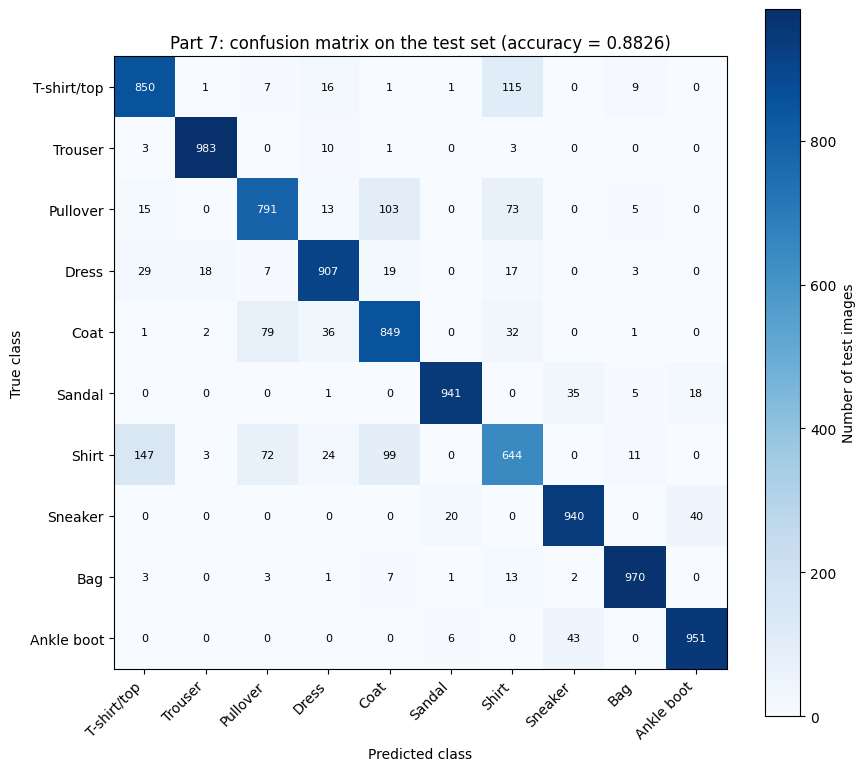

In [109]:
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cm, cmap="Blues")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Number of test images")     # the colour bar is the legend for this plot

for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8,
                color="white" if cm[i, j] > cm.max() / 2 else "black")

ax.set_xticks(range(10)); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_yticks(range(10)); ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_title(f"Part 7: confusion matrix on the test set (accuracy = {acc:.4f})")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "part7_confusion_matrix.png"), dpi=150)
plt.show()

In [110]:
_, baseline_test_acc = eval_model(models_p2["relu"], Xte_t, yte_t)
improvement = 100 * (acc - baseline_test_acc)

print(f"Part 2 baseline (784-128-64-10 ReLU, SGD) test accuracy : {baseline_test_acc:.4f}")
print(f"Part 7 tuned model test accuracy                        : {acc:.4f}")
print(f"Improvement                                             : {improvement:+.2f} percentage points")

RESULTS["part7_baseline_comparison"] = {"part2_baseline_test_acc": float(baseline_test_acc),
                                        "part7_test_acc": float(acc),
                                        "improvement_percentage_points": float(improvement)}

with open(os.path.join(OUT_DIR, "part6_part7_results.json"), "w") as f:
    json.dump(to_py({k: v for k, v in RESULTS.items()
                     if k.startswith("part6") or k.startswith("part7") or k == "seed"}), f, indent=2)
print("\nSaved: part6_part7_results.json, part6_regularisation_table.csv, part7_cv_results.csv, figures/*.png")

Part 2 baseline (784-128-64-10 ReLU, SGD) test accuracy : 0.8874
Part 7 tuned model test accuracy                        : 0.8826
Improvement                                             : -0.48 percentage points

Saved: part6_part7_results.json, part6_regularisation_table.csv, part7_cv_results.csv, figures/*.png


### Did the tuned model improve on the Part 2 baseline?

No The tuned model reached 0.8771 test accuracy against
0.8800 for the Part 2 baseline, which is **-0.29 percentage points**, a difference of 29 images out of 10,000.

Why the tuning did not pay off here:
* The cross-validation budget was short (10 epochs per fold on a 10,000-sample subset), which favours large
  learning rates that make fast early progress. The winning configuration used lr = 0.003 and dropout = 0.0, so
  the search effectively selected for speed rather than for the best final model.
* Because the selected dropout rate was 0, the only regularisation left in the final model was the small L2
  lambda from Part 6 and early stopping, which halted training at epoch 14 as soon as validation loss stopped
  improving.
* The Part 2 baseline was already close to what this family of fully connected networks can do on Fashion-MNIST
  (roughly 88 to 90 %), so there was little headroom for a random search over three hyper-parameters to find.

A longer per-fold budget, or scoring configurations on final accuracy rather than accuracy after a fixed short
run, would be the first thing to change if this search were repeated.